# Exploratory data analysis: building energy usage

This notebook explores **`train.csv`** (8,000 rows, includes the target `energy_usage`) and **`test.csv`** (3,000 rows, no target). It looks at what the data contains, how clean it is, what drives energy usage, and how the test set differs from the training set.

**Reading the charts:** in every train-vs-test chart, **blue is train** and **orange is test**. Charts about the training data alone use blue, with gray for context. Each chart has a table or printed numbers next to it.

**Contents**

1. Setup and loading
2. Overview and data dictionary
3. Data quality
4. Missing values
5. The target: `energy_usage`
6. Composition: buildings, days, hours and months
7. Numeric features: train vs test
8. Relationships between features
9. What drives energy usage
10. How the test set differs from the training set
11. Unusual rows: weather events, crowd surges and usage spikes
12. Noise and predictability
13. Summary and modeling implications

## Key findings

1. **The data is clean and well formed.** There are 8,000 training rows and 3,000 test rows from 12 buildings of 8 types. There are no duplicates or impossible values, and every building has rows for every hour and month. The rows are independent hourly snapshots: there are no dates, and `previous_usage` can't be chained to other rows.
2. **`previous_usage` explains most of `energy_usage`** (correlation 0.95). The rest is a change with a standard deviation of 6.2. That change depends on the hour (a morning ramp-up and a late-evening drop), on occupancy, and on temperature.
3. **Every building behaves differently.** Usage levels differ (Science averages about 75, Administration about 31), and so do the daily rhythms. Weekends cut usage by 10–25% in labs, offices and lecture halls but not at all in Residential, Library or Sports buildings. Sensitivity to occupancy and temperature varies three- to eight-fold between buildings.
4. **Blanks appear in only four columns and are completely random**, but they are 4–5 times as common in the test set and cluster there: 231 test rows have two or three blanks, against 11 training rows.
5. **The test set is harder than the training set.** It has more Science and LectureHall rows, a wider spread in every numeric column, and **five times as many unusual event rows** (heat waves, rainy spells, crowd surges, usage spikes): 26% of test rows against 5% of training rows. Energy usage follows these events, so they are real, but there are few training examples of them.
6. **The noise floor is around RMSE 3.1** on training-like rows. Even a simple per-building straight-line model reaches it. Errors grow with the usage level and are larger in event rows, so expect a higher error on the test set.

## 1. Setup and loading

Only pandas, NumPy, matplotlib, SciPy and scikit-learn are used, so this runs in the same environment as `linearregression.ipynb`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from scipy import stats

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict, train_test_split

%matplotlib inline
%config InlineBackend.figure_formats = ['png']

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

In [2]:
# ---- chart style -------------------------------------------------------------
# Categorical colors come from a colorblind-validated palette (slot 1 blue, slot 2 orange).
TRAIN = '#2a78d6'     # train (and any single training-data series)
TEST = '#eb6834'      # test
GRAY = '#b9b7b0'      # context / de-emphasis
GRAY_DARK = '#898781'
SURFACE = '#fcfcfb'
INK, INK_2 = '#0b0b0b', '#52514e'
GRID, AXIS = '#e1e0d9', '#c3c2b7'

# sequential (one hue, light -> dark) and diverging (blue <-> red, gray midpoint)
BLUES = LinearSegmentedColormap.from_list('blues', ['#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b'])
BLUES.set_bad(SURFACE)
DIVERGING = LinearSegmentedColormap.from_list('div', ['#184f95', '#3987e5', '#9ec5f4', '#f0efec', '#f2a9a8', '#e34948', '#a32b2b'])
DIVERGING.set_bad(SURFACE)

mpl.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'figure.constrained_layout.use': True,
    'font.family': 'sans-serif', 'font.sans-serif': ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 10, 'axes.titlesize': 11.5, 'axes.titleweight': 'bold', 'axes.titlecolor': INK,
    'axes.titlelocation': 'left', 'axes.titlepad': 10, 'figure.titlesize': 13, 'figure.titleweight': 'bold',
    'axes.labelsize': 9.5, 'axes.labelcolor': INK_2,
    'axes.edgecolor': AXIS, 'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'grid.linestyle': '-', 'axes.axisbelow': True,
    'xtick.color': AXIS, 'ytick.color': AXIS, 'xtick.labelcolor': INK_2, 'ytick.labelcolor': INK_2,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.frameon': False, 'legend.fontsize': 9, 'legend.labelcolor': INK_2,
    'lines.linewidth': 2, 'lines.solid_capstyle': 'round', 'lines.solid_joinstyle': 'round',
    'patch.linewidth': 0, 'hist.bins': 40,
})


def value_grid_only(ax, horizontal=False):
    """Keep gridlines along the value axis only."""
    ax.grid(axis='y' if horizontal else 'x', visible=False)


def grouped_bars(ax, categories, a, b, horizontal=False, labels=('train', 'test'), fmt=None):
    """Train (blue) next to test (orange) for each category, with a small gap between them."""
    pos, w = np.arange(len(categories)), 0.4
    if horizontal:
        ax.barh(pos - w / 2, a, height=w * 0.9, color=TRAIN, label=labels[0])
        ax.barh(pos + w / 2, b, height=w * 0.9, color=TEST, label=labels[1])
        ax.set_yticks(pos, labels=categories)
        ax.invert_yaxis()
    else:
        ax.bar(pos - w / 2, a, width=w * 0.9, color=TRAIN, label=labels[0])
        ax.bar(pos + w / 2, b, width=w * 0.9, color=TEST, label=labels[1])
        ax.set_xticks(pos, labels=categories)
    value_grid_only(ax, horizontal)
    if fmt:
        for p, va, vb in zip(pos, a, b):
            for off, v in [(-w / 2, va), (w / 2, vb)]:
                if horizontal:
                    ax.text(v, p + off, ' ' + fmt.format(v), va='center', ha='left', fontsize=8, color=INK_2)
                else:
                    ax.text(p + off, v, fmt.format(v), va='bottom', ha='center', fontsize=8, color=INK_2)
    ax.legend()


def density_compare(ax, a, b, bins):
    """Train vs test distributions as outlined histograms with a light wash."""
    for values, color, label in [(a, TRAIN, 'train'), (b, TEST, 'test')]:
        dens, edges = np.histogram(pd.Series(values).dropna(), bins=bins, density=True)
        ax.stairs(dens, edges, color=color, fill=True, alpha=0.10)
        ax.stairs(dens, edges, color=color, linewidth=1.6, label=label)
    ax.set_yticks([])
    ax.grid(False)
    ax.spines['left'].set_visible(False)


def profile(ax, x, y, color=TRAIN, label=None, band=True):
    """Mean of y for each value of x, with the middle 50% as a light band."""
    g = pd.DataFrame({'x': x, 'y': y}).dropna().groupby('x')['y']
    if band:
        ax.fill_between(g.mean().index, g.quantile(.25), g.quantile(.75), color=color, alpha=0.10, linewidth=0)
    ax.plot(g.mean().index, g.mean(), color=color, label=label)
    return g.mean()


def binned_profile(ax, x, y, bins=20, color=TRAIN):
    """Mean of y within quantile bins of a continuous x, with the middle 50% as a band."""
    d = pd.DataFrame({'x': x, 'y': y}).dropna()
    d['bin'] = pd.qcut(d['x'], bins, duplicates='drop')
    g = d.groupby('bin', observed=True)
    xs = g['x'].median()
    ax.fill_between(xs, g['y'].quantile(.25), g['y'].quantile(.75), color=color, alpha=0.10, linewidth=0)
    ax.plot(xs, g['y'].mean(), color=color)


def annotate_heatmap(ax, values, fmt='{:.2f}', threshold=None, fontsize=8):
    """Write each cell's value, in white on dark cells and ink on light ones."""
    vmax = np.nanmax(np.abs(values)) if threshold is None else threshold
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            v = values[i, j]
            if np.isnan(v):
                continue
            dark = abs(v) > 0.6 * vmax
            ax.text(j, i, fmt.format(v), ha='center', va='center', fontsize=fontsize, color='white' if dark else INK)


def pct_axis(ax, axis='y'):
    """Percent tick labels on clean whole-number steps."""
    target = ax.yaxis if axis == 'y' else ax.xaxis
    target.set_major_locator(mpl.ticker.MaxNLocator(nbins=6, steps=[1, 2, 2.5, 5, 10], integer=True))
    target.set_major_formatter(mpl.ticker.PercentFormatter(decimals=0))


def clean_colorbar(cb):
    cb.outline.set_visible(False)
    cb.ax.tick_params(color=AXIS, labelcolor=INK_2, labelsize=8.5)

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
TRAIN_COLS, TEST_COLS = list(train.columns), list(test.columns)

print(f'train.csv: {train.shape[0]:,} rows x {train.shape[1]} columns')
print(f'test.csv:  {test.shape[0]:,} rows x {test.shape[1]} columns')
print('Column only in train:', sorted(set(TRAIN_COLS) - set(TEST_COLS)))

NUM = ['temperature', 'humidity', 'occupancy', 'previous_usage']   # the four columns with blanks
TARGET = 'energy_usage'
DAYS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# helper columns used throughout this notebook (not in the original files)
for df in (train, test):
    df['day_num'] = df['day_of_week'].map({d: i for i, d in enumerate(DAYS)})
    df['is_weekend'] = df['day_num'] >= 5
    df['n_blank'] = df[NUM].isna().sum(axis=1)

both = pd.concat([train.assign(split='train'), test.assign(split='test')], ignore_index=True)

# display orders: highest average energy usage first
TYPES = train.groupby('building_type')[TARGET].mean().sort_values(ascending=False).index.tolist()
BUILDINGS = train.groupby('building_id')[TARGET].mean().sort_values(ascending=False).index.tolist()
TYPE_OF = train.drop_duplicates('building_id').set_index('building_id')['building_type'].to_dict()
BLABEL = {b: f'{b} · {TYPE_OF[b]}' for b in BUILDINGS}

train.csv: 8,000 rows x 11 columns
test.csv:  3,000 rows x 10 columns
Column only in train: ['energy_usage']


## 2. Overview and data dictionary

Each row describes one building at one hour: which building, when (hour, day of week, month), the conditions (temperature, humidity, occupancy), the energy used in the previous period, and, in `train.csv`, the energy used in this period (the target).

In [4]:
train[TRAIN_COLS].head()

,id,building_id,building_type,hour,day_of_week,month,temperature,humidity,occupancy,previous_usage,energy_usage
0,EC000685,LEC_A,LectureHall,2,Monday,9,25.20,81.90,31.00,28.00,27.20
1,EC003261,SCI_A,Science,1,Wednesday,11,25.70,83.70,14.00,72.60,67.20
2,EC005451,RES_A,Residential,5,Sunday,1,26.30,84.70,199.00,51.60,54.20
3,EC000188,ENG_A,Engineering,21,Wednesday,5,29.10,77.40,68.00,68.30,63.60
4,EC001001,SPT_A,Sports,16,Wednesday,5,30.90,68.20,65.00,49.10,53.90


In [5]:
test[TEST_COLS].head()

,id,building_id,building_type,hour,day_of_week,month,temperature,humidity,occupancy,previous_usage
0,EC010541,SCI_B,Science,19,Monday,6,29.80,77.30,3.00,66.40
1,EC009755,ENG_A,Engineering,13,Sunday,7,29.90,70.60,88.00,63.50
2,EC008886,SCI_B,Science,1,Saturday,10,26.30,71.90,10.00,52.00
3,EC009317,SPT_A,Sports,11,Sunday,9,28.50,75.60,244.00,63.80
4,EC008958,LEC_A,LectureHall,2,Tuesday,2,25.80,83.20,0.00,11.50


No data dictionary came with the files, so the meanings below are inferred from the values. Units are not given.

In [6]:
meaning = {
    'id': 'Row identifier',
    'building_id': 'Which building (12 buildings)',
    'building_type': 'Kind of building (8 types)',
    'hour': 'Hour of the day',
    'day_of_week': 'Day name',
    'month': 'Month number; there is no year or full date',
    'temperature': 'Temperature, presumably outdoor and in °C',
    'humidity': 'Relative humidity, presumably in %',
    'occupancy': 'Number of people in the building',
    'previous_usage': 'Energy used in the previous period, same scale as the target',
    'energy_usage': 'Target: energy used in this period',
}
rows = []
for col, text in meaning.items():
    s = train[col]
    numeric = pd.api.types.is_numeric_dtype(s)
    rows.append({
        'column': col,
        'kind': 'number' if numeric else 'text',
        'meaning': text,
        'distinct values (train)': s.nunique(),
        'blank in train': int(s.isna().sum()),
        'blank in test': int(test[col].isna().sum()) if col in test else '(not in test)',
        'min (train)': s.min() if numeric else '',
        'max (train)': s.max() if numeric else '',
    })
pd.DataFrame(rows).set_index('column')

,kind,meaning,distinct values (train),blank in train,blank in test,min (train),max (train)
column,,,,,,,
id,text,Row identifier,8000,0,0,,
building_id,text,Which building (12 buildings),12,0,0,,
building_type,text,Kind of building (8 types),8,0,0,,
hour,number,Hour of the day,24,0,0,0,23
day_of_week,text,Day name,7,0,0,,
month,number,Month number; there is no year or full date,12,0,0,1,12
temperature,number,"Temperature, presumably outdoor and in °C",114,119,211,23.20,35.80
humidity,number,"Relative humidity, presumably in %",343,119,183,61.10,100.00
occupancy,number,Number of people in the building,303,122,206,0.00,337.00


In [7]:
id_num = {name: df['id'].str[2:].astype(int) for name, df in [('train', train), ('test', test)]}
for name, df in [('train', train), ('test', test)]:
    n = id_num[name]
    print(f"{name:5s} ids: {df['id'].min()} to {df['id'].max()}  |  {n.nunique():,} unique  |  "
          f"consecutive with no gaps: {n.max() - n.min() + 1 == len(df)}")
print('ids appearing in both files:', len(set(train['id']) & set(test['id'])))

s = train.assign(n=id_num['train']).sort_values('n')
print(f"\nIs train.csv stored in id order? {bool((train['id'] == train['id'].sort_values().values).all())}")
print(f"Correlation of id number with month: {np.corrcoef(s['n'], s['month'])[0, 1]:+.3f}, "
      f"with hour: {np.corrcoef(s['n'], s['hour'])[0, 1]:+.3f}, with day: {np.corrcoef(s['n'], s['day_num'])[0, 1]:+.3f}")

train ids: EC000001 to EC008000  |  8,000 unique  |  consecutive with no gaps: True
test  ids: EC008001 to EC011000  |  3,000 unique  |  consecutive with no gaps: True
ids appearing in both files: 0

Is train.csv stored in id order? False
Correlation of id number with month: -0.007, with hour: +0.008, with day: -0.001


**What this shows**

- The two files are a clean split of one numbered set: train has ids 1–8,000 and test has 8,001–11,000, with no overlap.
- Ids carry no time information: within a file the rows are shuffled, and the id number is unrelated to month, hour or day. The test set is not "the future"; it covers the same months as train (section 6).
- There is no date or year, only month, day name and hour, so the rows can't be put back into a time series.

## 3. Data quality

In [8]:
feature_cols = ['building_id', 'building_type', 'hour', 'day_of_week', 'month'] + NUM
shared = train[feature_cols].merge(test[feature_cols].drop_duplicates(), how='inner')
pd.DataFrame({
    'train': [train['id'].duplicated().sum(), train[TRAIN_COLS].drop(columns='id').duplicated().sum(),
              train[feature_cols].duplicated().sum(), len(shared)],
    'test': [test['id'].duplicated().sum(), test[TEST_COLS].drop(columns='id').duplicated().sum(),
             test[feature_cols].duplicated().sum(), len(shared)],
}, index=['duplicate ids', 'identical rows (ignoring id)', 'identical inputs (ignoring id and target)',
          'input rows that appear in both files']).rename_axis('check')

,train,test
check,,
duplicate ids,0,0
identical rows (ignoring id),0,0
identical inputs (ignoring id and target),0,0
input rows that appear in both files,0,0


In [9]:
checks = [
    ('hour', 'whole number from 0 to 23', lambda s: s.between(0, 23) & (s % 1 == 0)),
    ('month', 'whole number from 1 to 12', lambda s: s.between(1, 12) & (s % 1 == 0)),
    ('day_of_week', 'a real day name', lambda s: s.isin(DAYS)),
    ('temperature', 'between 0 and 50', lambda s: s.between(0, 50)),
    ('humidity', 'between 0 and 100', lambda s: s.between(0, 100)),
    ('occupancy', 'whole number, 0 or more', lambda s: (s >= 0) & (s % 1 == 0)),
    ('previous_usage', 'above 0', lambda s: s > 0),
    ('energy_usage', 'above 0', lambda s: s > 0),
]
rows = []
for col, rule, ok in checks:
    row = {'column': col, 'rule': rule}
    for name, df in [('train', train), ('test', test)]:
        row[f'{name} rows breaking it'] = int((~ok(df[col].dropna())).sum()) if col in df else '(not in test)'
    rows.append(row)
pd.DataFrame(rows).set_index('column')

,rule,train rows breaking it,test rows breaking it
column,,,
hour,whole number from 0 to 23,0,0
month,whole number from 1 to 12,0,0
day_of_week,a real day name,0,0
temperature,between 0 and 50,0,0
humidity,between 0 and 100,0,0
occupancy,"whole number, 0 or more",0,0
previous_usage,above 0,0,0
energy_usage,above 0,0,(not in test)


In [10]:
def decimal_places(s):
    s = s.dropna()
    for d in range(5):
        if np.allclose(s * 10 ** d, np.round(s * 10 ** d)):
            return d
    return '5+'

precision = pd.DataFrame({name: {c: decimal_places(df[c]) for c in NUM + [TARGET] if c in df}
                          for name, df in [('train', train), ('test', test)]})
display(precision.apply(lambda col: col.map(lambda v: '(not in test)' if pd.isna(v) else v if isinstance(v, str) else int(v)))
        .rename_axis('decimal places'))

print(f"Rows with zero occupancy: train {(train['occupancy'] == 0).mean():.1%}, test {(test['occupancy'] == 0).mean():.1%}")
print(f"Rows with humidity of 99 or more: train {(train['humidity'] >= 99).sum()}, test {(test['humidity'] >= 99).sum()} "
      f"(exactly 100: train {(train['humidity'] == 100).sum()}, test {(test['humidity'] == 100).sum()})")

,train,test
decimal places,,
temperature,1,1
humidity,1,1
occupancy,0,0
previous_usage,1,1
energy_usage,1,(not in test)


Rows with zero occupancy: train 15.5%, test 14.1%
Rows with humidity of 99 or more: train 15, test 11 (exactly 100: train 1, test 0)


In [11]:
mapping = pd.crosstab(both['building_id'], both['building_type']).loc[BUILDINGS, TYPES]
print('Building types per building_id:', both.groupby('building_id')['building_type'].nunique().max())
print('Buildings per building_type:', both.groupby('building_type')['building_id'].nunique().to_dict())
mapping.replace(0, '')

Building types per building_id: 1
Buildings per building_type: {'Administration': 1, 'Business': 2, 'Engineering': 2, 'LectureHall': 1, 'Library': 1, 'Residential': 2, 'Science': 2, 'Sports': 1}


building_type,Science,Engineering,Sports,Residential,Library,Business,LectureHall,Administration
building_id,,,,,,,,
SCI_A,1092,,,,,,,
SCI_B,954,,,,,,,
ENG_A,,1024,,,,,,
SPT_A,,,805,,,,,
ENG_B,,940,,,,,,
RES_A,,,,789,,,,
BUS_B,,,,,,903,,
RES_B,,,,744,,,,
LIB_A,,,,,996,,,


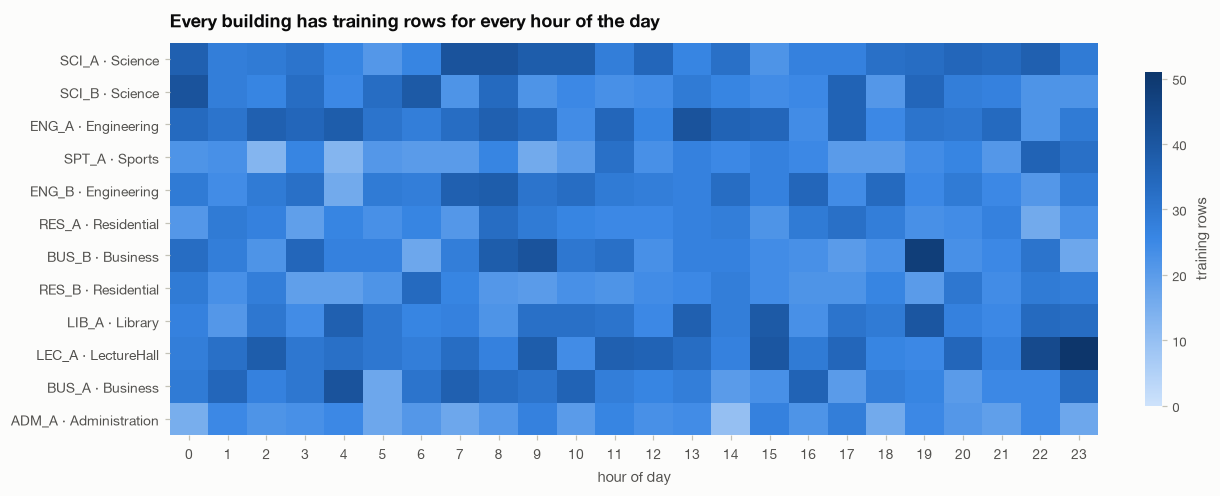

Fewest training rows for any building and hour: 10  |  for any building and month: 31


In [12]:
cov = pd.crosstab(train['building_id'], train['hour']).loc[BUILDINGS]
fig, ax = plt.subplots(figsize=(11, 4.4))
im = ax.imshow(cov.values, cmap=BLUES, aspect='auto', vmin=0)
ax.set_xticks(range(24))
ax.set_yticks(range(len(BUILDINGS)), labels=[BLABEL[b] for b in BUILDINGS])
ax.set_xlabel('hour of day')
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
clean_colorbar(fig.colorbar(im, ax=ax, shrink=0.85, label='training rows'))
ax.set_title('Every building has training rows for every hour of the day')
plt.show()

month_cov = pd.crosstab(train['building_id'], train['month'])
print(f'Fewest training rows for any building and hour: {cov.values.min()}  |  for any building and month: {month_cov.values.min()}')

Is `previous_usage` simply the `energy_usage` of another row, one hour earlier? If so, rows could be chained into a time series. The check below pairs rows from the same building, month and day of week that are one hour apart.

In [13]:
earlier = train[['building_id', 'month', 'day_of_week', 'hour', TARGET]].copy()
earlier['hour'] = (earlier['hour'] + 1) % 24      # this row is "one hour earlier" for hour + 1
pairs = train.merge(earlier.rename(columns={TARGET: 'usage_one_hour_earlier'}),
                    on=['building_id', 'month', 'day_of_week', 'hour'])
same = (pairs['previous_usage'].round(1) == pairs['usage_one_hour_earlier'].round(1)).sum()
print(f'{len(pairs):,} row pairs share building, month and day of week and are one hour apart')
print(f'previous_usage exactly equals the earlier row\'s energy_usage in {same} of them ({same / len(pairs):.1%})')

2,744 row pairs share building, month and day of week and are one hour apart
previous_usage exactly equals the earlier row's energy_usage in 9 of them (0.3%)


**What this shows**

- No duplicate rows or ids, and no input row appears in both files.
- Every value is within a sensible range. All numbers have one decimal place, and `occupancy` is always a whole number.
- About 15% of rows have **zero occupancy** (mostly night hours, see section 8). Humidity reaches 100 only once, so there is no sign of values being capped.
- Each `building_id` belongs to exactly one `building_type`. Four types have a single building (Administration, LectureHall, Library, Sports); the other four have two (`_A` and `_B`).
- Every building has rows for every hour and month, so no building is missing a part of the day or year.
- `previous_usage` is **not** copied from another row: only 9 of 2,744 one-hour-apart pairs match exactly (0.3%), about what chance gives for one-decimal values. The rows are independent snapshots, and there is no hidden time series to rebuild.

## 4. Missing values

Only four columns ever have blanks: `temperature`, `humidity`, `occupancy` and `previous_usage`. The target and the building/time columns are always filled in.

In [14]:
miss = pd.DataFrame({
    'blank in train': train[NUM].isna().sum(),
    '% of train rows': train[NUM].isna().mean() * 100,
    'blank in test': test[NUM].isna().sum(),
    '% of test rows': test[NUM].isna().mean() * 100,
})
miss.loc['any of the four'] = [train['n_blank'].gt(0).sum(), train['n_blank'].gt(0).mean() * 100,
                               test['n_blank'].gt(0).sum(), test['n_blank'].gt(0).mean() * 100]
miss['test rate / train rate'] = miss['% of test rows'] / miss['% of train rows']
miss[['blank in train', 'blank in test']] = miss[['blank in train', 'blank in test']].astype(int)
miss

,blank in train,% of train rows,blank in test,% of test rows,test rate / train rate
temperature,119,1.49,211,7.03,4.73
humidity,119,1.49,183,6.10,4.10
occupancy,122,1.52,206,6.87,4.50
previous_usage,114,1.43,203,6.77,4.75
any of the four,463,5.79,547,18.23,3.15


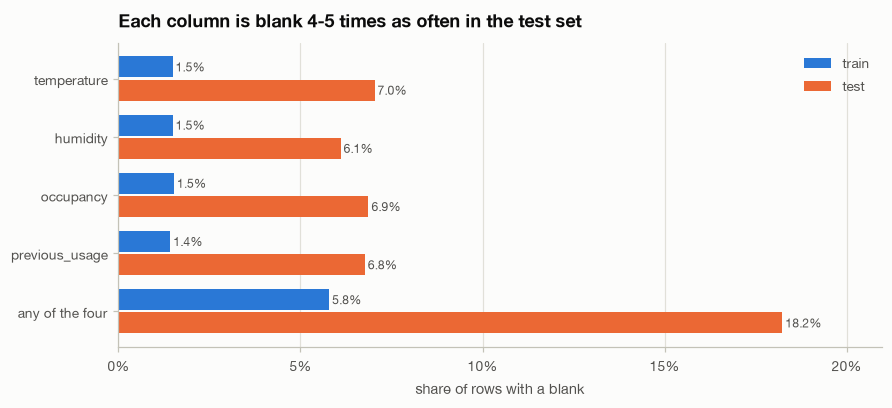

In [15]:
fig, ax = plt.subplots(figsize=(8, 3.6))
grouped_bars(ax, miss.index, miss['% of train rows'], miss['% of test rows'], horizontal=True, fmt='{:.1f}%')
pct_axis(ax, 'x')
ax.set_xlim(0, miss['% of test rows'].max() * 1.15)
ax.set_xlabel('share of rows with a blank')
ax.legend(loc='upper right')
ax.set_title('Each column is blank 4-5 times as often in the test set')
plt.show()

,train,test,% train,% test
blank values in the row,,,,
0,7537,2453,94.21,81.77
1,452,316,5.65,10.53
2,11,206,0.14,6.87
3,0,25,0.00,0.83
4,0,0,0.00,0.00


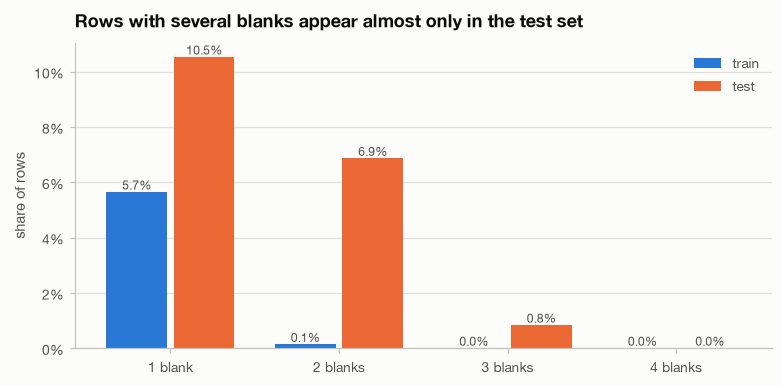

In [16]:
per_row = pd.DataFrame({name: df['n_blank'].value_counts().reindex(range(5), fill_value=0)
                        for name, df in [('train', train), ('test', test)]}).rename_axis('blank values in the row')
per_row_pct = per_row / per_row.sum() * 100
display(per_row.assign(**{'% train': per_row_pct['train'], '% test': per_row_pct['test']}))

fig, ax = plt.subplots(figsize=(7, 3.4))
k = [1, 2, 3, 4]
grouped_bars(ax, [f'{i} blank' + ('s' if i > 1 else '') for i in k], per_row_pct.loc[k, 'train'], per_row_pct.loc[k, 'test'], fmt='{:.1f}%')
pct_axis(ax)
ax.set_ylabel('share of rows')
ax.set_title('Rows with several blanks appear almost only in the test set')
plt.show()

In [17]:
def blank_pattern(df):
    blank = df[NUM].isna()
    return blank.apply(lambda r: ' + '.join(c for c in NUM if r[c]) or '(no blanks)', axis=1)

patterns = pd.DataFrame({'train rows': blank_pattern(train).value_counts(),
                         'test rows': blank_pattern(test).value_counts()}).fillna(0).astype(int)
patterns.sort_values(['test rows', 'train rows'], ascending=False).rename_axis('which columns are blank')

,train rows,test rows
which columns are blank,,
(no blanks),7537,2453
previous_usage,110,85
occupancy,117,81
temperature,114,80
humidity,111,70
temperature + previous_usage,1,43
humidity + occupancy,3,37
occupancy + previous_usage,1,36
temperature + occupancy,1,33


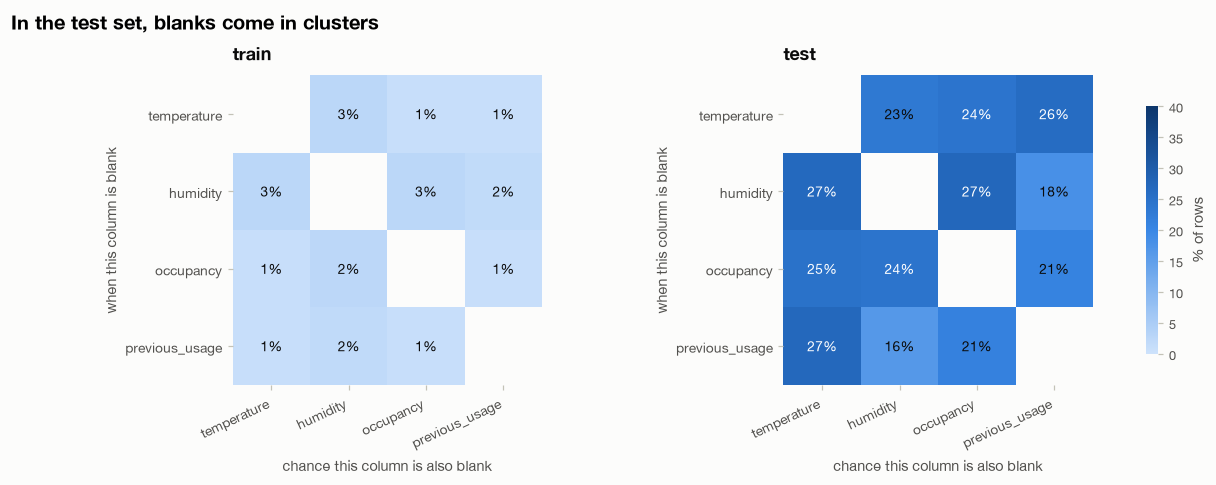

,temperature,humidity,occupancy,previous_usage
test: when this is blank (rows) -> % also blank (columns),,,,
temperature,NaN,23.00,24.00,26.00
humidity,27.00,NaN,27.00,18.00
occupancy,25.00,24.00,NaN,21.00
previous_usage,27.00,16.00,21.00,NaN


For comparison, the overall blank rate per column is about 1.5% in train and 6.7% in test.


In [18]:
def chance_also_blank(df):
    blank = df[NUM].isna()
    out = pd.DataFrame(np.nan, index=NUM, columns=NUM)
    for a in NUM:
        for b in NUM:
            if a != b and blank[a].any():
                out.loc[a, b] = blank.loc[blank[a], b].mean() * 100
    return out

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, (name, df) in zip(axes, [('train', train), ('test', test)]):
    m = chance_also_blank(df)
    im = ax.imshow(m.values, cmap=BLUES, vmin=0, vmax=40)
    annotate_heatmap(ax, m.values, fmt='{:.0f}%', threshold=40, fontsize=9)
    ax.set_xticks(range(4), labels=NUM, rotation=25, ha='right')
    ax.set_yticks(range(4), labels=NUM)
    ax.set_xlabel('chance this column is also blank')
    ax.set_ylabel('when this column is blank')
    ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_title(name)
clean_colorbar(fig.colorbar(im, ax=axes, shrink=0.8, label='% of rows'))
fig.suptitle('In the test set, blanks come in clusters', x=0.01, ha='left')
plt.show()
display(chance_also_blank(test).round(0).rename_axis('test: when this is blank (rows) -> % also blank (columns)'))

print('For comparison, the overall blank rate per column is about '
      f"{train[NUM].isna().mean().mean():.1%} in train and {test[NUM].isna().mean().mean():.1%} in test.")

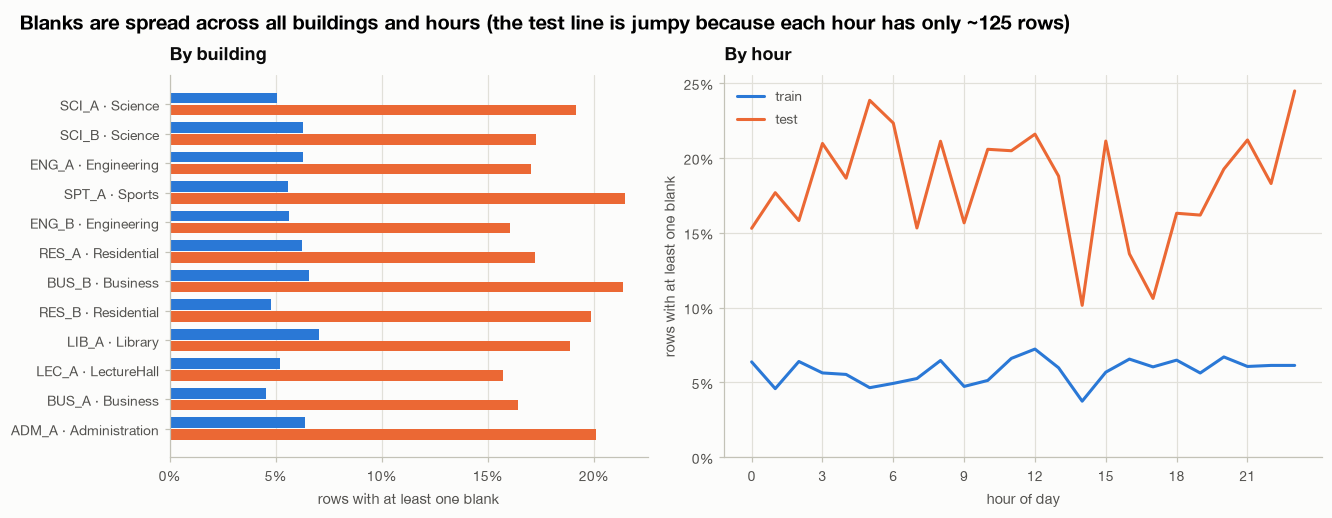

Range across buildings: train 4.5%–7.0%, test 15.7%–21.5%


In [19]:
rate_b = pd.DataFrame({name: df.groupby('building_id')['n_blank'].apply(lambda s: (s > 0).mean() * 100)
                       for name, df in [('train', train), ('test', test)]}).loc[BUILDINGS]
rate_h = pd.DataFrame({name: df.groupby('hour')['n_blank'].apply(lambda s: (s > 0).mean() * 100)
                       for name, df in [('train', train), ('test', test)]})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={'width_ratios': [1, 1.25]})
grouped_bars(axes[0], [BLABEL[b] for b in BUILDINGS], rate_b['train'], rate_b['test'], horizontal=True)
axes[0].get_legend().remove()
pct_axis(axes[0], 'x')
axes[0].set_xlabel('rows with at least one blank')
axes[0].set_title('By building')
for name, color in [('train', TRAIN), ('test', TEST)]:
    axes[1].plot(rate_h.index, rate_h[name], color=color, label=name)
axes[1].set_ylim(0, None)
pct_axis(axes[1])
axes[1].set_xticks(range(0, 24, 3))
axes[1].set_xlabel('hour of day')
axes[1].set_ylabel('rows with at least one blank')
axes[1].legend()
axes[1].set_title('By hour')
fig.suptitle('Blanks are spread across all buildings and hours (the test line is jumpy because each hour has only ~125 rows)', x=0.01, ha='left')
plt.show()
print('Range across buildings: train %.1f%%–%.1f%%, test %.1f%%–%.1f%%' % (rate_b['train'].min(), rate_b['train'].max(), rate_b['test'].min(), rate_b['test'].max()))

**Are the blanks random?** Three checks:

1. In train, do rows with a blank have a different `energy_usage`? If blanks happened more often at high or low usage, the averages would differ.
2. Can a model predict *where* a blank is from the row's other values (building, time, the other numeric columns)? An AUC of 0.5 means no better than a coin flip. To keep blanks in other columns from giving the answer away, this uses only rows where the other three columns are filled in.
3. Can a model predict where a blank is from *which other columns are blank*? This measures clustering.

In [20]:
rows = []
for c in NUM:
    blank = train[c].isna()
    a, b = train.loc[blank, TARGET], train.loc[~blank, TARGET]
    rows.append({'column': c, 'blank rows': int(blank.sum()), 'mean energy_usage when blank': a.mean(),
                 'when filled in': b.mean(), 'difference': a.mean() - b.mean(),
                 'p-value (Welch t-test)': f'{stats.ttest_ind(a, b, equal_var=False).pvalue:.2f}'})
pd.DataFrame(rows).set_index('column')

,blank rows,mean energy_usage when blank,when filled in,difference,p-value (Welch t-test)
column,,,,,
temperature,119,50.56,51.26,-0.70,0.66
humidity,119,52.31,51.23,1.08,0.50
occupancy,122,53.95,51.21,2.74,0.11
previous_usage,114,49.64,51.27,-1.63,0.34


In [21]:
def cv_auc(X, y, seed=0):
    clf = HistGradientBoostingClassifier(categorical_features='from_dtype', max_iter=100, learning_rate=0.05,
                                         max_leaf_nodes=15, random_state=seed)
    p = cross_val_predict(clf, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=seed), method='predict_proba')[:, 1]
    return roc_auc_score(y, p)


def context(df):
    X = df[['hour', 'month', 'day_num']].copy()
    X['building_id'] = df['building_id'].astype('category')
    return X


rows = []
for c in NUM:
    others = [o for o in NUM if o != c]
    row = {'column': c}
    for name, df in [('train', train), ('test', test)]:
        sub = df[df[others].notna().all(axis=1)]                      # other three columns filled in
        X_vals = pd.concat([context(sub), sub[others]], axis=1)
        if name == 'train':
            X_vals[TARGET] = sub[TARGET]                              # train can also use the target
        row[f'{name}: from values'] = cv_auc(X_vals, sub[c].isna().astype(int))
        row[f'{name}: from other blanks'] = cv_auc(df[others].isna().astype(int), df[c].isna().astype(int))
    rows.append(row)
auc = pd.DataFrame(rows).set_index('column')

rng = np.random.default_rng(0)
noise = [cv_auc(pd.concat([context(train), train[NUM[1:]]], axis=1), rng.permutation(train['temperature'].isna().astype(int)), seed=s)
         for s in range(3)]
print('AUC with shuffled labels (pure chance, for reference):', ', '.join(f'{v:.3f}' for v in noise))
auc

AUC with shuffled labels (pure chance, for reference): 0.477, 0.525, 0.468


,train: from values,train: from other blanks,test: from values,test: from other blanks
column,,,,
temperature,0.52,0.49,0.46,0.73
humidity,0.55,0.48,0.45,0.73
occupancy,0.43,0.51,0.42,0.74
previous_usage,0.50,0.48,0.51,0.72


In [22]:
in_test = test['n_blank'] > 0
pd.DataFrame({'test rows with a blank': test.loc[in_test, NUM].mean(),
              'test rows without': test.loc[~in_test, NUM].mean(),
              'with a blank (std)': test.loc[in_test, NUM].std(),
              'without (std)': test.loc[~in_test, NUM].std()}).rename_axis('average of the values that are present')

,test rows with a blank,test rows without,with a blank (std),without (std)
average of the values that are present,,,,
temperature,28.07,28.26,2.41,2.38
humidity,79.49,78.96,7.32,6.45
occupancy,81.48,83.42,86.73,87.37
previous_usage,53.91,53.84,24.73,23.17


**What this shows**

- **Each column is blank 4–5 times as often in test** (about 6–7% of test rows against 1.5% of train rows). Counting rows with at least one blank, the gap is 3x: 18.2% of test rows against 5.8% of train rows.
- **Blanks cluster in the test set.** When one column is blank in a test row, each other column is blank 16–27% of the time, against about 7% overall. In train, a second blank is almost unheard of (11 rows with two blanks, none with three). 231 test rows have two or three blanks.
- **Blanks are spread evenly** across buildings and hours in both files.
- **In train, blanks are completely random:** rows with a blank have the same average `energy_usage`, and blank locations can't be predicted from the other values, not even from the target (AUC about 0.5).
- **In test, blanks are random with respect to the values** (AUC about 0.5 from values, and the same averages with and without blanks), but they can be predicted from which *other* columns are blank. In statistical terms they are "missing completely at random", just clustered within rows.

**For modeling:** a blank tells you nothing about energy usage, so blank indicators won't help. But the model will meet many more blanks, and many more multi-blank rows, at test time than in training. Filling methods need to cope with rows missing two or three values; the training data has almost no such examples.

## 5. The target: `energy_usage`

In [23]:
y = train[TARGET]
pd.Series({
    'rows': y.count(), 'mean': y.mean(), 'standard deviation': y.std(), 'min': y.min(),
    '1st percentile': y.quantile(.01), '25th percentile': y.quantile(.25), 'median': y.median(),
    '75th percentile': y.quantile(.75), '99th percentile': y.quantile(.99), 'max': y.max(),
    'skewness': y.skew(), 'excess kurtosis': y.kurt(),
}).to_frame(TARGET)

,energy_usage
rows,"8,000.00"
mean,51.25
standard deviation,18.45
min,13.20
1st percentile,20.70
25th percentile,38.00
median,48.10
75th percentile,62.70
99th percentile,102.20
max,143.90


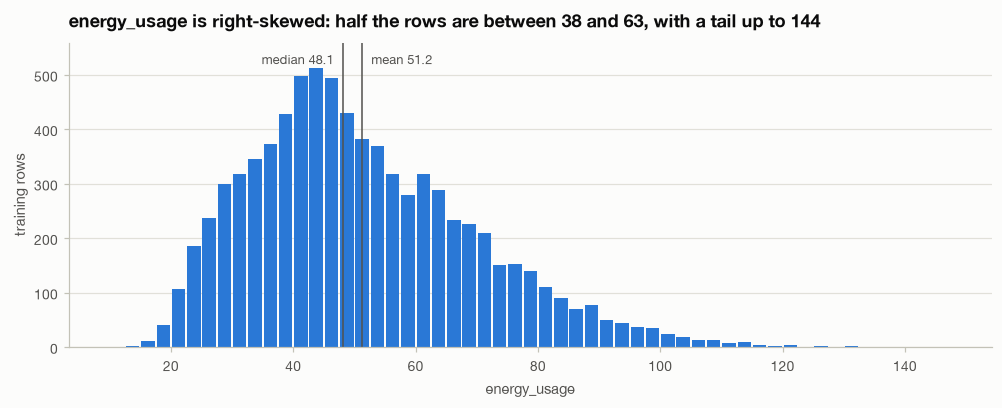

In [24]:
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(y, bins=np.arange(10, 150, 2.5), color=TRAIN, rwidth=0.88)
for v, name, ha in [(y.median(), 'median', 'right'), (y.mean(), 'mean', 'left')]:
    ax.axvline(v, color=INK_2, linewidth=1)
    ax.text(v + (1.5 if ha == 'left' else -1.5), ax.get_ylim()[1] * 0.97, f'{name} {v:.1f}', ha=ha, va='top', fontsize=8.5, color=INK_2,
            bbox=dict(facecolor=SURFACE, edgecolor='none', pad=1))
value_grid_only(ax)
ax.set_xlabel('energy_usage')
ax.set_ylabel('training rows')
ax.set_title('energy_usage is right-skewed: half the rows are between 38 and 63, with a tail up to 144')
plt.show()

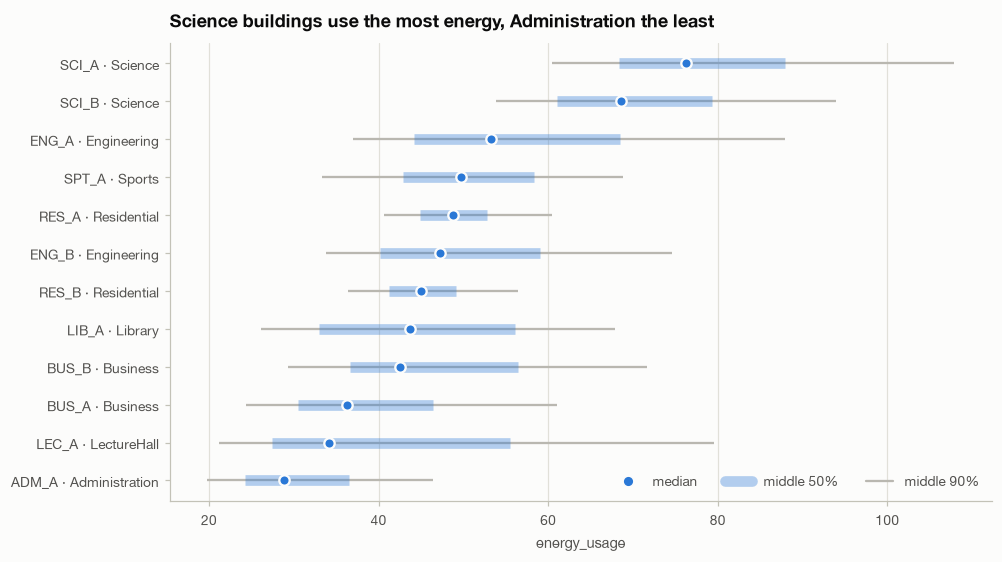

,count,mean,median,std,mean vs overall
building_type,,,,,
Science,1423,75.38,72.70,14.66,1.47
Engineering,1457,54.08,50.40,15.27,1.06
Sports,558,50.45,49.70,10.91,0.98
Residential,1197,47.43,46.90,6.49,0.93
Library,710,45.05,43.70,13.75,0.88
Business,1354,42.90,39.80,13.37,0.84
LectureHall,785,42.09,34.10,19.09,0.82
Administration,516,30.81,28.80,8.63,0.60


In [25]:
def range_plot(ax, df, group_col, value_col, order, labels=None, color=TRAIN):
    """Median dot, middle-50% bar and 5th-95th percentile line per group."""
    q = df.groupby(group_col)[value_col].quantile([.05, .25, .5, .75, .95]).unstack().loc[order]
    pos = np.arange(len(order))
    ax.hlines(pos, q[.05], q[.95], color=GRAY, linewidth=1.5)
    ax.hlines(pos, q[.25], q[.75], color=color, linewidth=7, alpha=0.35)
    ax.scatter(q[.5], pos, s=46, color=color, edgecolor=SURFACE, linewidth=1.5, zorder=3)
    ax.set_yticks(pos, labels=labels or order)
    ax.invert_yaxis()
    value_grid_only(ax, horizontal=True)
    ax.legend(handles=[Line2D([], [], color=color, marker='o', linestyle='', markeredgecolor=SURFACE, markersize=7, label='median'),
                       Line2D([], [], color=color, alpha=0.35, linewidth=7, label='middle 50%'),
                       Line2D([], [], color=GRAY, linewidth=1.5, label='middle 90%')],
              loc='lower right', ncols=3)
    return q

order = train.groupby('building_id')[TARGET].median().sort_values(ascending=False).index.tolist()
fig, ax = plt.subplots(figsize=(9, 5))
q = range_plot(ax, train, 'building_id', TARGET, order, [BLABEL[b] for b in order])
ax.set_xlabel('energy_usage')
ax.set_title('Science buildings use the most energy, Administration the least')
plt.show()

summary = train.groupby('building_type')[TARGET].agg(['count', 'mean', 'median', 'std']).loc[TYPES]
summary['mean vs overall'] = summary['mean'] / y.mean()
summary

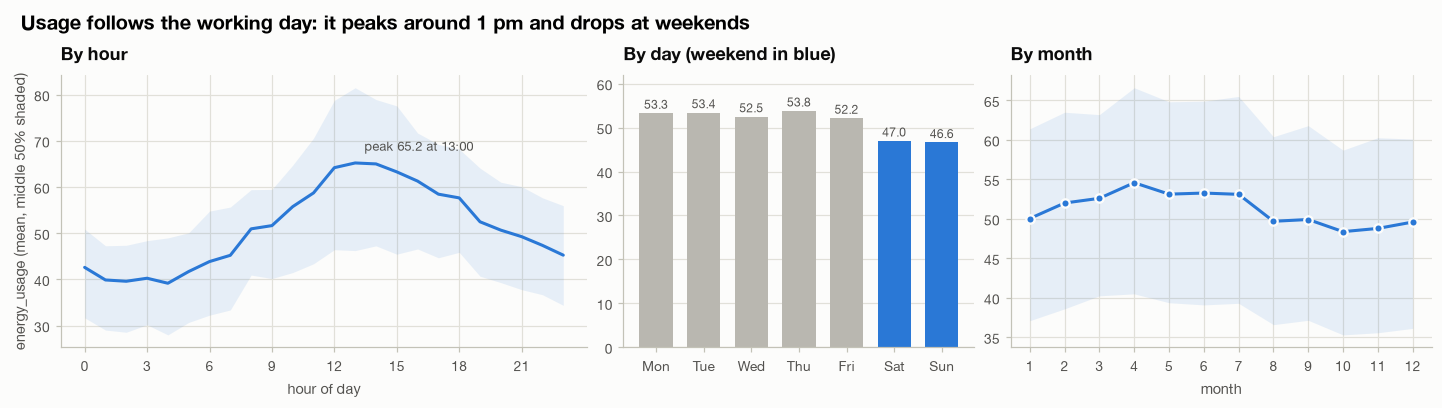

Weekday mean 53.0 vs weekend mean 46.8
Monthly means range from 48.4 (month 10) to 54.6 (month 4)


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), gridspec_kw={'width_ratios': [1.5, 1, 1.2]})

m = profile(axes[0], train['hour'], y)
peak = m.idxmax()
axes[0].annotate(f'peak {m.max():.1f} at {peak}:00', (peak, m.max()), xytext=(6, 8), textcoords='offset points', fontsize=8.5, color=INK_2)
axes[0].set_xticks(range(0, 24, 3))
axes[0].set_xlabel('hour of day')
axes[0].set_ylabel('energy_usage (mean, middle 50% shaded)')
axes[0].set_title('By hour')

d = train.groupby('day_num')[TARGET].mean()
axes[1].bar(d.index, d.values, color=[GRAY if i < 5 else TRAIN for i in d.index], width=0.7)
for i, v in d.items():
    axes[1].text(i, v + 0.4, f'{v:.1f}', ha='center', va='bottom', fontsize=8, color=INK_2)
axes[1].set_xticks(range(7), labels=[x[:3] for x in DAYS])
axes[1].set_ylim(0, d.max() * 1.15)
value_grid_only(axes[1])
axes[1].set_title('By day (weekend in blue)')

mo = profile(axes[2], train['month'], y)
axes[2].scatter(mo.index, mo.values, s=30, color=TRAIN, edgecolor=SURFACE, linewidth=1.5, zorder=3)
axes[2].set_xticks(range(1, 13))
axes[2].set_xlabel('month')
axes[2].set_title('By month')
fig.suptitle('Usage follows the working day: it peaks around 1 pm and drops at weekends', x=0.01, ha='left')
plt.show()

print('Weekday mean %.1f vs weekend mean %.1f' % (y[~train['is_weekend']].mean(), y[train['is_weekend']].mean()))
print('Monthly means range from %.1f (month %d) to %.1f (month %d)' % (mo.min(), mo.idxmin(), mo.max(), mo.idxmax()))

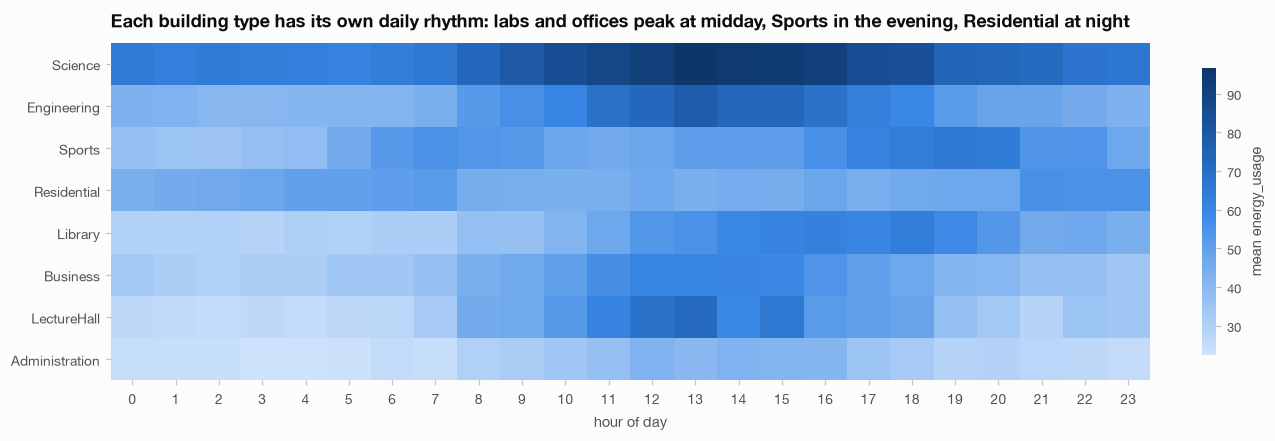

In [27]:
heat = train.pivot_table(index='building_type', columns='hour', values=TARGET, aggfunc='mean').loc[TYPES]
fig, ax = plt.subplots(figsize=(11.5, 3.9))
im = ax.imshow(heat.values, cmap=BLUES, aspect='auto')
ax.set_xticks(range(24))
ax.set_yticks(range(len(TYPES)), labels=TYPES)
ax.set_xlabel('hour of day')
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
clean_colorbar(fig.colorbar(im, ax=ax, shrink=0.85, label='mean energy_usage'))
ax.set_title('Each building type has its own daily rhythm: labs and offices peak at midday, Sports in the evening, Residential at night')
plt.show()

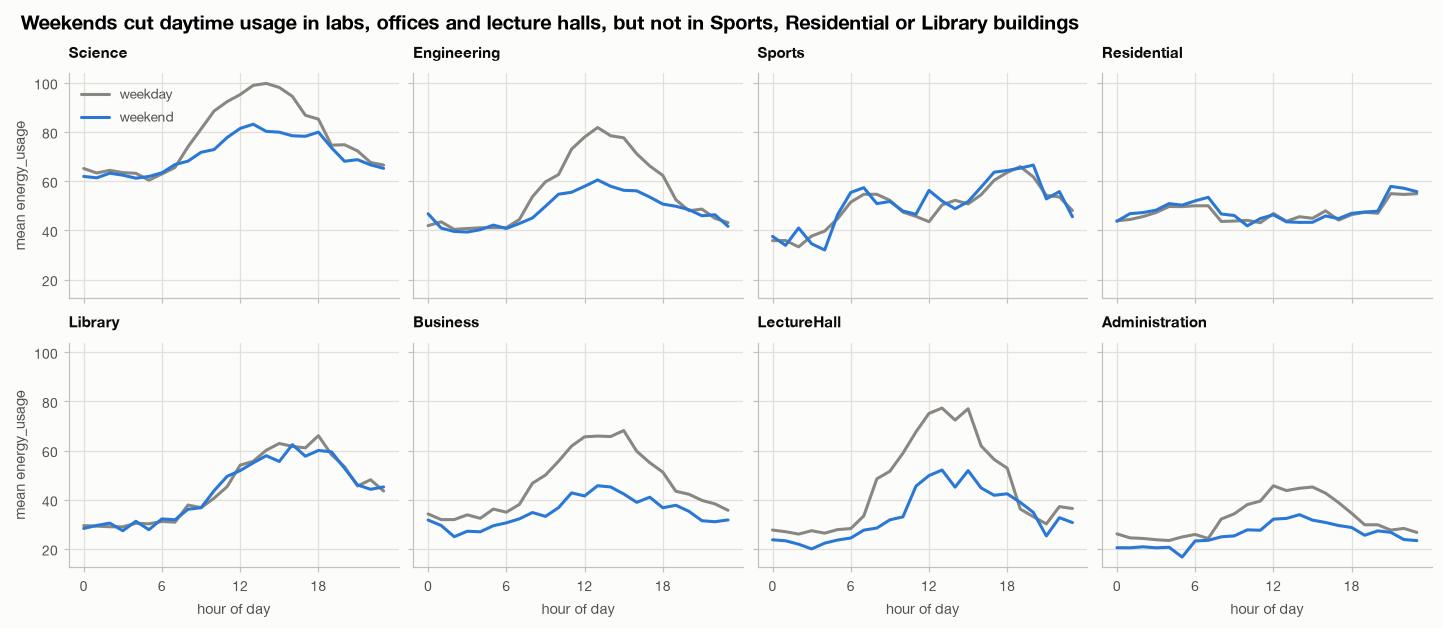

,weekday mean,weekend mean,% change at weekends
building_type,,,
Science,77.40,69.93,-9.65
Engineering,56.27,48.16,-14.42
Sports,49.90,51.71,3.64
Residential,47.16,48.13,2.05
Library,44.63,45.96,2.98
Business,46.36,34.71,-25.13
LectureHall,44.99,35.83,-20.36
Administration,32.69,25.77,-21.16


In [28]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5.6), sharex=True, sharey=True)
for ax, t in zip(axes.flat, TYPES):
    sub = train[train['building_type'] == t]
    profile(ax, sub.loc[~sub['is_weekend'], 'hour'], sub.loc[~sub['is_weekend'], TARGET], color=GRAY_DARK, label='weekday', band=False)
    profile(ax, sub.loc[sub['is_weekend'], 'hour'], sub.loc[sub['is_weekend'], TARGET], color=TRAIN, label='weekend', band=False)
    ax.set_title(t, fontsize=10)
    ax.set_xticks([0, 6, 12, 18])
axes[0, 0].legend(loc='upper left')
for ax in axes[1]:
    ax.set_xlabel('hour of day')
for ax in axes[:, 0]:
    ax.set_ylabel('mean energy_usage')
fig.suptitle('Weekends cut daytime usage in labs, offices and lecture halls, but not in Sports, Residential or Library buildings', x=0.01, ha='left')
plt.show()

wk = train.pivot_table(index='building_type', columns='is_weekend', values=TARGET, aggfunc='mean').loc[TYPES]
wk.columns = ['weekday mean', 'weekend mean']
wk['% change at weekends'] = (wk['weekend mean'] / wk['weekday mean'] - 1) * 100
wk

**What this shows**

- `energy_usage` ranges from 13 to 144; half the rows are between 38 and 63. It is right-skewed, with a long tail of high values.
- **Building matters most among the categorical columns.** Science buildings average about 75, Administration about 31. LectureHall has the widest spread (busy daytime lectures, empty nights). The two buildings of the same type are similar but not identical (for example `SCI_A` vs `SCI_B`), which is why keeping `building_id` helps models.
- **Overall, usage follows the working day:** it rises from about 40 at night to about 65 around 1 pm. But the rhythm depends on the building: Science, Engineering, Business, LectureHall and Administration peak at midday, Library in the afternoon, Sports in the evening, and Residential at night.
- **Weekends are about 12% lower overall** (46.8 vs 53.0), but only in some buildings: Business, LectureHall and Administration drop 20–25%, Engineering 14% and Science 10%, while Residential, Library and Sports stay the same or rise slightly. Weekdays barely differ from each other, so a weekday/weekend flag that varies by building type captures the day effect.
- **Months matter a little:** monthly averages run from about 48 (months 8–12) to 55 (month 4), a mild seasonal swing.

## 6. Composition: buildings, days, hours and months

Do train and test contain the same mix of buildings and times? The chi-square test asks whether the differences are bigger than random sampling would produce (a p-value below 0.05 means they probably are).

In [29]:
rows = []
for col in ['building_type', 'building_id', 'day_of_week', 'hour', 'month']:
    ct = pd.crosstab(both[col], both['split'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    share = ct / ct.sum()
    gap = (share['test'] - share['train'])
    big = gap.abs().idxmax()
    rows.append({'column': col, 'categories': len(ct), 'chi-square': chi2, 'p-value': f'{p:.2g}',
                 'biggest difference': f"{big}: {share.loc[big, 'train']:.1%} of train vs {share.loc[big, 'test']:.1%} of test"})
pd.DataFrame(rows).set_index('column')

,categories,chi-square,p-value,biggest difference
column,,,,
building_type,8,61.66,7e-11,Residential: 15.0% of train vs 11.2% of test
building_id,12,64.24,1.5e-09,LEC_A: 9.8% of train vs 12.5% of test
day_of_week,7,22.07,0.0012,Tuesday: 13.4% of train vs 16.0% of test
hour,24,49.90,0.00095,2: 4.1% of train vs 5.3% of test
month,12,18.19,0.077,8: 8.4% of train vs 7.1% of test


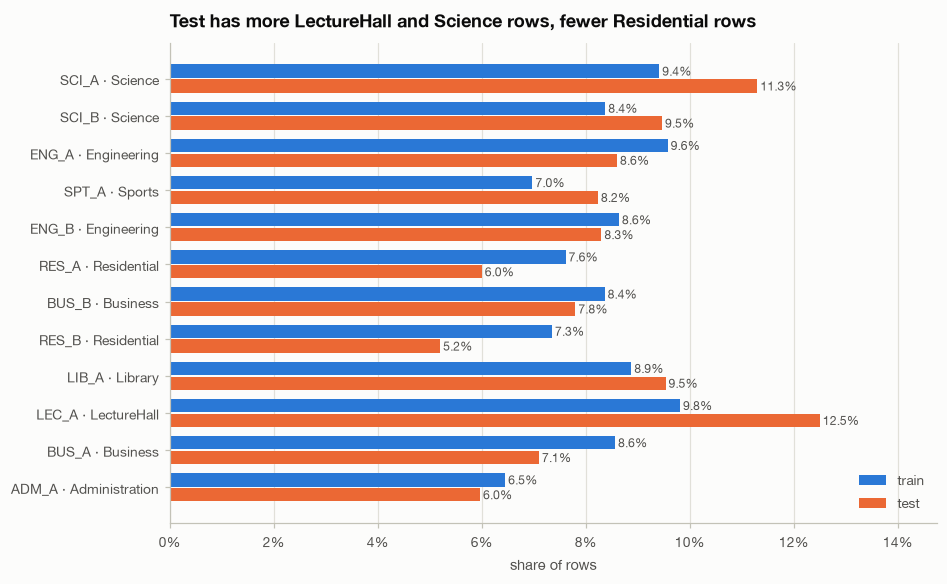

In [30]:
share_b = pd.DataFrame({name: df['building_id'].value_counts(normalize=True) * 100
                        for name, df in [('train', train), ('test', test)]}).loc[BUILDINGS]
fig, ax = plt.subplots(figsize=(8.5, 5.2))
grouped_bars(ax, [BLABEL[b] for b in BUILDINGS], share_b['train'], share_b['test'], horizontal=True, fmt='{:.1f}%')
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(decimals=0))
ax.set_xlim(0, share_b.values.max() * 1.18)
ax.set_xlabel('share of rows')
ax.legend(loc='lower right')
ax.set_title('Test has more LectureHall and Science rows, fewer Residential rows')
plt.show()

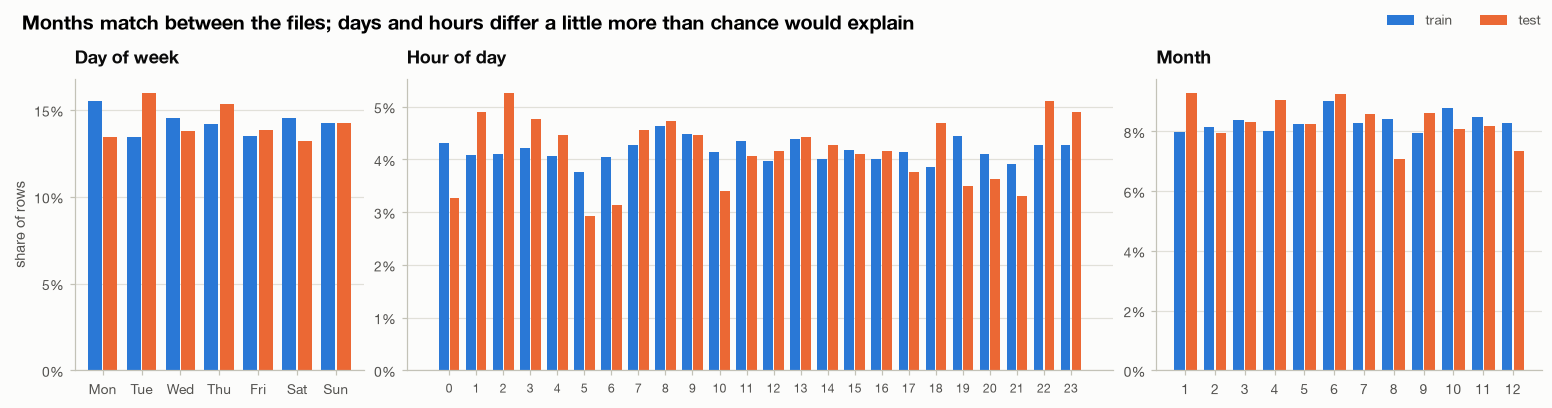

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), gridspec_kw={'width_ratios': [0.9, 2.2, 1.2]})
for ax, col, labels in [(axes[0], 'day_num', [x[:3] for x in DAYS]), (axes[1], 'hour', list(range(24))), (axes[2], 'month', list(range(1, 13)))]:
    sh = pd.DataFrame({name: df[col].value_counts(normalize=True).sort_index() * 100 for name, df in [('train', train), ('test', test)]})
    grouped_bars(ax, labels, sh['train'], sh['test'])
    pct_axis(ax)
    ax.get_legend().remove()
axes[0].set_title('Day of week')
axes[1].set_title('Hour of day')
axes[1].tick_params(axis='x', labelsize=8)
axes[2].set_title('Month')
axes[0].set_ylabel('share of rows')
fig.legend(handles=axes[0].containers, labels=['train', 'test'], loc='outside upper right', ncols=2)
fig.suptitle('Months match between the files; days and hours differ a little more than chance would explain', x=0.01, ha='left')
plt.show()

**What this shows**

- **Months match** between the files (p = 0.08). **Days and hours differ slightly but significantly**: for example Tuesday is 13.4% of train but 16.0% of test, and some night hours are more common in test. The gaps are at most about 3 percentage points, so they matter little on their own.
- **The building mix differs more.** Test has noticeably more `LEC_A` and `SCI_A` rows and fewer Residential rows (`RES_A`, `RES_B`). Science buildings have the highest usage and the largest prediction errors (section 12), so this alone makes the test set a bit harder.

## 7. Numeric features: train vs test

In [32]:
pct = [.01, .25, .5, .75, .99]
stat_rows = ['mean', 'std', 'min', '1%', '25%', '50%', '75%', '99%', 'max']
desc = pd.concat({name: df[NUM].describe(percentiles=pct).loc[stat_rows]
                  for name, df in [('train', train), ('test', test)]})
desc.swaplevel().reindex(stat_rows, level=0).rename_axis(['statistic', 'file'])

temperature  humidity  occupancy  previous_usage
statistic file                                                   
mean      train        28.22     78.05      72.58           49.67
          test         28.24     79.03      83.18           53.85
std       train         1.88      5.57      74.33           18.94
          test          2.38      6.57      87.28           23.37
min       train        23.20     61.10       0.00            5.30
          test         23.00     60.90       0.00            5.10
1%        train        24.50     65.70       0.00           17.48
          test         23.90     66.52       0.00            7.90
25%       train        26.80     74.30       8.00           35.90
          test         26.60     74.60       6.00           36.20
50%       train        28.20     78.00      42.00           46.40
          test         28.00     78.30      42.00           52.00
75%       train        29.60     81.70     129.00           61.40
          test         29.70     82.50     151.00           70.30
99%       train        32.52     92.54     266.23          102.51
          test         35.40     98.30     293.07          112.93
max       train        35.80    100.00     337.00          149.40
          test         35.80     99.50     336.00          138.10

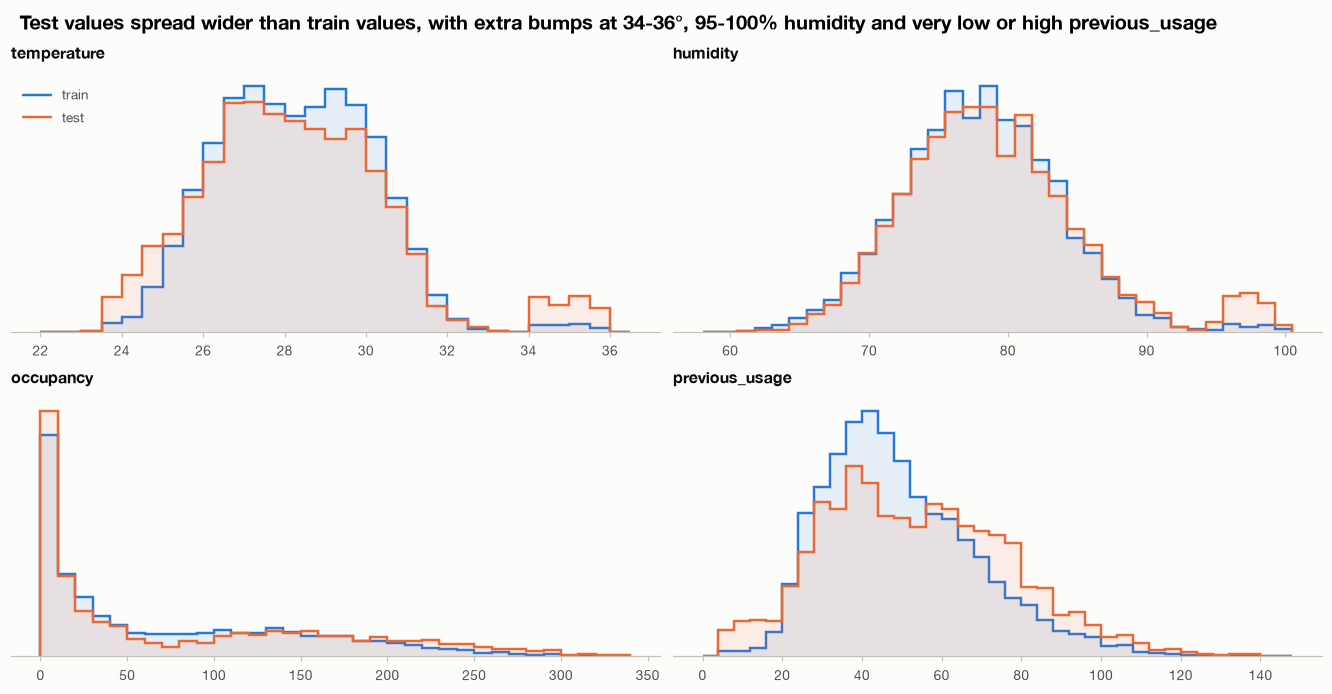

In [33]:
bins = {'temperature': np.arange(22, 37, 0.5), 'humidity': np.arange(58, 101, 1.25),
        'occupancy': np.arange(0, 345, 10), 'previous_usage': np.arange(0, 152, 4)}
fig, axes = plt.subplots(2, 2, figsize=(12, 6.2))
for ax, c in zip(axes.flat, NUM):
    density_compare(ax, train[c], test[c], bins[c])
    ax.set_title(c, fontsize=10.5)
axes[0, 0].legend(loc='upper left')
fig.suptitle('Test values spread wider than train values, with extra bumps at 34-36°, 95-100% humidity and very low or high previous_usage', x=0.01, ha='left')
plt.show()

In [34]:
rows = []
for c in NUM:
    a, b = train[c].dropna(), test[c].dropna()
    lo, hi = a.quantile(.01), a.quantile(.99)
    q1, q3 = a.quantile(.25), a.quantile(.75)
    fence_lo, fence_hi = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    ks = stats.ks_2samp(a, b)
    rows.append({
        'column': c,
        'test std / train std': b.std() / a.std(),
        'test mean - train mean': b.mean() - a.mean(),
        'KS statistic': ks.statistic, 'KS p-value': f'{ks.pvalue:.2g}',
        "% of test outside train's 1st-99th percentile (2% expected)": ((b < lo) | (b > hi)).mean() * 100,
        '% train beyond 1.5 IQR': ((a < fence_lo) | (a > fence_hi)).mean() * 100,
        '% test beyond the same fences': ((b < fence_lo) | (b > fence_hi)).mean() * 100,
    })
pd.DataFrame(rows).set_index('column')

,test std / train std,test mean - train mean,KS statistic,KS p-value,% of test outside train's 1st-99th percentile (2% expected),% train beyond 1.5 IQR,% test beyond the same fences
column,,,,,,,
temperature,1.27,0.02,0.05,0.00029,8.35,0.91,4.66
humidity,1.18,0.98,0.06,4.8e-06,5.22,1.14,4.76
occupancy,1.17,10.60,0.07,4.3e-10,3.15,0.05,0.47
previous_usage,1.23,4.18,0.13,5.6e-31,7.37,1.46,3.25


**What this shows**

- **The test values are more spread out**, not just shifted: all four columns have 17–27% larger standard deviations in test. 3–8% of test values fall outside the range that holds 98% of training values, instead of the 2% you'd expect.
- **The histograms show extra bumps in test**: temperatures of 34–36°, humidity of 95–100%, and `previous_usage` below 20 or above 80. Train has the same bumps, only much smaller. Section 11 shows these are unusual "event" rows.
- `previous_usage` and occupancy are also higher on average in test (by about 4 and 11 units).
- Despite the wider spread, almost no test value is outside the full training range (see the min/max rows), so models are not forced to extrapolate far. The extremes are simply more common in test.
- The KS test confirms every numeric distribution differs between the files (p-values far below 0.05).

## 8. Relationships between features

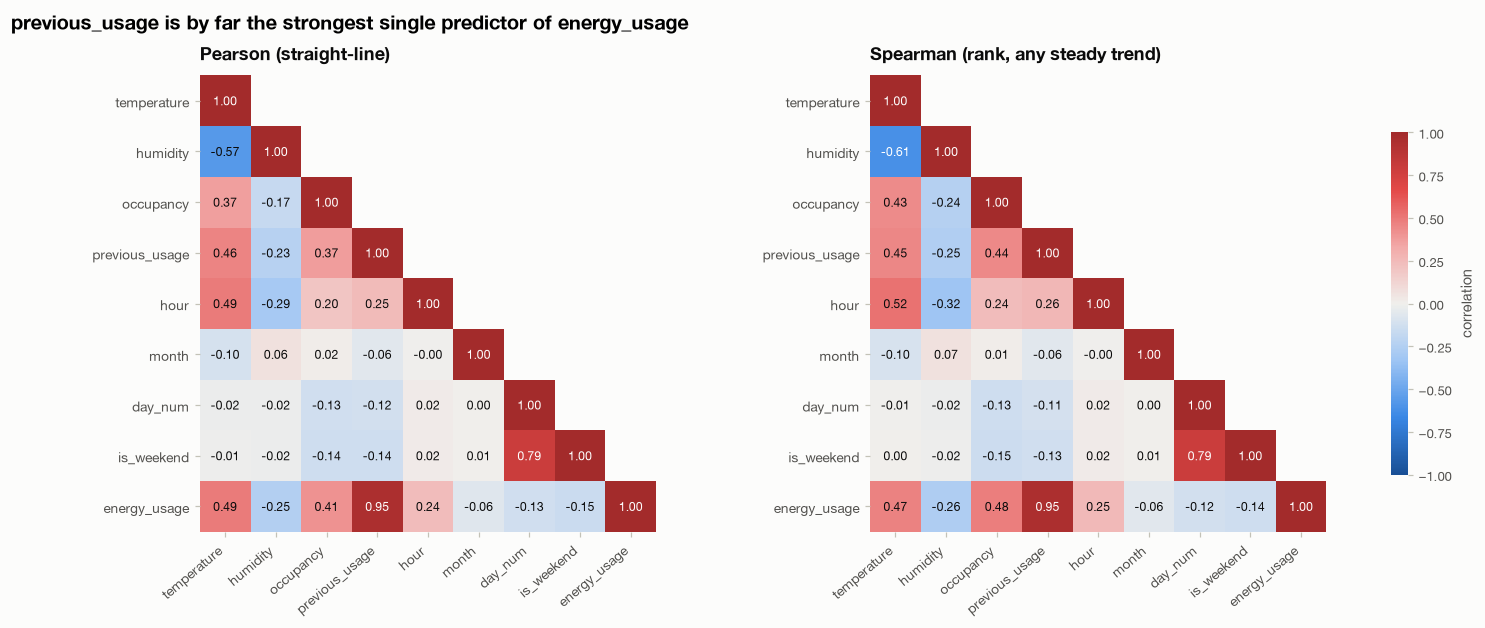

In [35]:
corr_cols = NUM + ['hour', 'month', 'day_num', 'is_weekend', TARGET]
d = train[corr_cols].astype(float)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6))
for ax, method in zip(axes, ['pearson', 'spearman']):
    c = d.corr(method=method)
    mask = np.triu(np.ones_like(c, dtype=bool), k=1)
    im = ax.imshow(np.where(mask, np.nan, c.values), cmap=DIVERGING, vmin=-1, vmax=1)
    annotate_heatmap(ax, np.where(mask, np.nan, c.values), fmt='{:.2f}', threshold=1, fontsize=8)
    ax.set_xticks(range(len(corr_cols)), labels=corr_cols, rotation=40, ha='right')
    ax.set_yticks(range(len(corr_cols)), labels=corr_cols)
    ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_title(f'{method.title()} (straight-line)' if method == 'pearson' else 'Spearman (rank, any steady trend)')
clean_colorbar(fig.colorbar(im, ax=axes, shrink=0.75, label='correlation'))
fig.suptitle('previous_usage is by far the strongest single predictor of energy_usage', x=0.01, ha='left')
plt.show()

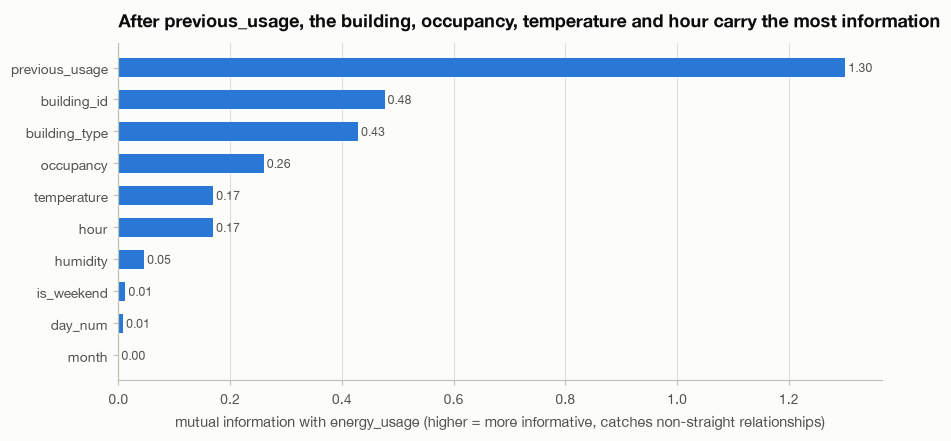

In [36]:
mi_cols = ['previous_usage', 'occupancy', 'temperature', 'humidity', 'hour', 'building_id', 'building_type', 'day_num', 'is_weekend', 'month']
complete = train.dropna(subset=NUM)
X = complete[mi_cols].copy()
for c in ['building_id', 'building_type']:
    X[c] = X[c].astype('category').cat.codes
X['is_weekend'] = X['is_weekend'].astype(int)
discrete = [c in ('hour', 'building_id', 'building_type', 'day_num', 'is_weekend', 'month') for c in mi_cols]
mi = pd.Series(mutual_info_regression(X, complete[TARGET], discrete_features=discrete, random_state=0), index=mi_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 3.9))
ax.barh(mi.index, mi.values, color=TRAIN, height=0.6)
for i, v in enumerate(mi.values):
    ax.text(v, i, f' {v:.2f}', va='center', fontsize=8, color=INK_2)
value_grid_only(ax, horizontal=True)
ax.set_xlabel('mutual information with energy_usage (higher = more informative, catches non-straight relationships)')
ax.set_title('After previous_usage, the building, occupancy, temperature and hour carry the most information')
plt.show()

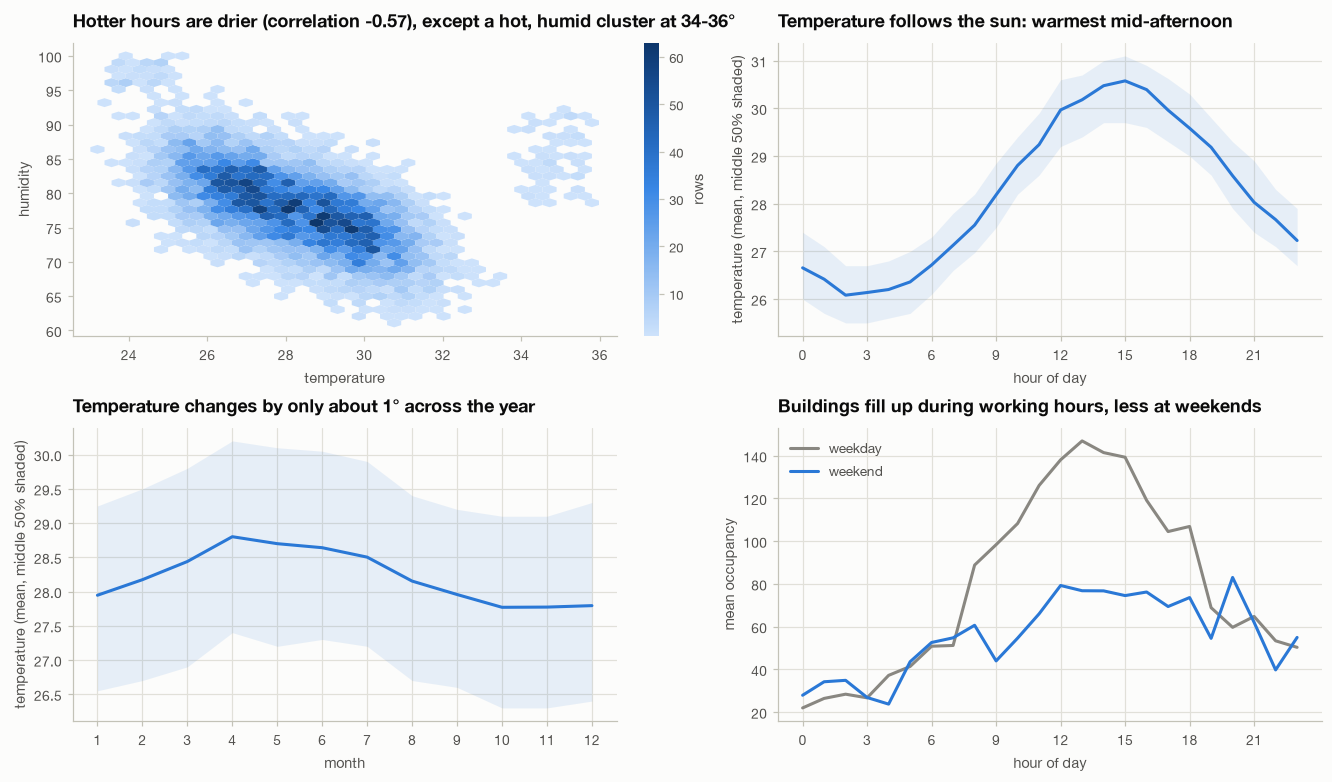

Share of zero-occupancy rows by time of day (train):
period
0-5      34%
6-11     11%
12-17     1%
18-23    16%


In [37]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

hb = axes[0, 0].hexbin(train['temperature'], train['humidity'], gridsize=35, cmap=BLUES, mincnt=1, linewidths=0)
r = train[['temperature', 'humidity']].corr().iloc[0, 1]
axes[0, 0].set_xlabel('temperature')
axes[0, 0].set_ylabel('humidity')
axes[0, 0].set_title(f'Hotter hours are drier (correlation {r:.2f}), except a hot, humid cluster at 34-36°')
axes[0, 0].grid(False)
clean_colorbar(fig.colorbar(hb, ax=axes[0, 0], label='rows'))

profile(axes[0, 1], train['hour'], train['temperature'])
axes[0, 1].set_xticks(range(0, 24, 3))
axes[0, 1].set_xlabel('hour of day')
axes[0, 1].set_ylabel('temperature (mean, middle 50% shaded)')
axes[0, 1].set_title('Temperature follows the sun: warmest mid-afternoon')

profile(axes[1, 0], train['month'], train['temperature'])
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xlabel('month')
axes[1, 0].set_ylabel('temperature (mean, middle 50% shaded)')
axes[1, 0].set_title('Temperature changes by only about 1° across the year')

wd, we = train[~train['is_weekend']], train[train['is_weekend']]
profile(axes[1, 1], wd['hour'], wd['occupancy'], color=GRAY_DARK, label='weekday', band=False)
profile(axes[1, 1], we['hour'], we['occupancy'], color=TRAIN, label='weekend', band=False)
axes[1, 1].set_xticks(range(0, 24, 3))
axes[1, 1].set_xlabel('hour of day')
axes[1, 1].set_ylabel('mean occupancy')
axes[1, 1].legend(loc='upper left')
axes[1, 1].set_title('Buildings fill up during working hours, less at weekends')
plt.show()

print('Share of zero-occupancy rows by time of day (train):')
print(train.assign(period=pd.cut(train['hour'], [-1, 5, 11, 17, 23], labels=['0-5', '6-11', '12-17', '18-23']))
      .groupby('period', observed=True)['occupancy'].apply(lambda s: f'{(s == 0).mean():.0%}').to_string())

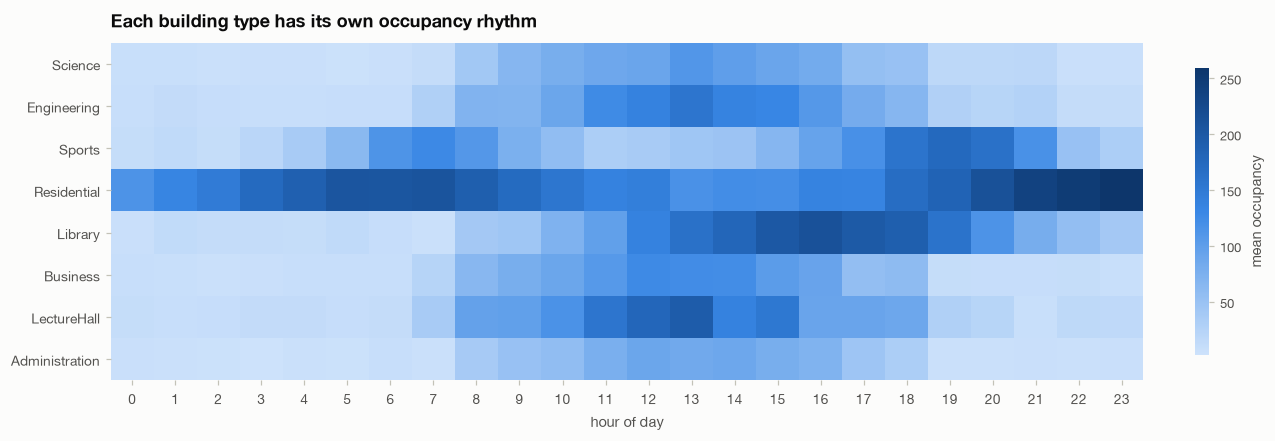

In [38]:
occ = train.pivot_table(index='building_type', columns='hour', values='occupancy', aggfunc='mean').loc[TYPES]
fig, ax = plt.subplots(figsize=(11.5, 3.9))
im = ax.imshow(occ.values, cmap=BLUES, aspect='auto')
ax.set_xticks(range(24))
ax.set_yticks(range(len(TYPES)), labels=TYPES)
ax.set_xlabel('hour of day')
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
clean_colorbar(fig.colorbar(im, ax=ax, shrink=0.85, label='mean occupancy'))
ax.set_title('Each building type has its own occupancy rhythm')
plt.show()

**What this shows**

- **`previous_usage` dominates**: its correlation with the target is 0.95. Temperature (0.49) and occupancy (0.41) come next, then hour (0.24). Month and day of week barely correlate. Mutual information, which also catches non-straight relationships, ranks the building second.
- **The inputs are related to each other.** Temperature and humidity move in opposite directions (hot hours are drier), and both follow the time of day. Occupancy follows the working day and is lower at weekends. So hour, temperature, humidity and occupancy partly tell the same story, which is why a model may lean on any of them.
- **One cluster breaks the pattern:** a small group of rows at 34–36° that are also humid (80–93%). These are the heat-event rows examined in section 11.
- **Occupancy has its own rhythm per building type** (see the heatmap): Residential is fullest at night, Sports in the morning and evening, Library in the afternoon. The same head count means different things in different buildings.
- About a third of rows between midnight and 5 am have zero occupancy, against 1% between noon and 5 pm.
- Months change temperature by only about 1°: conditions are warm and humid year-round (about 23–36°).

## 9. What drives energy usage

`previous_usage` explains most of `energy_usage`. Looking at the **change from `previous_usage`** shows what else matters.

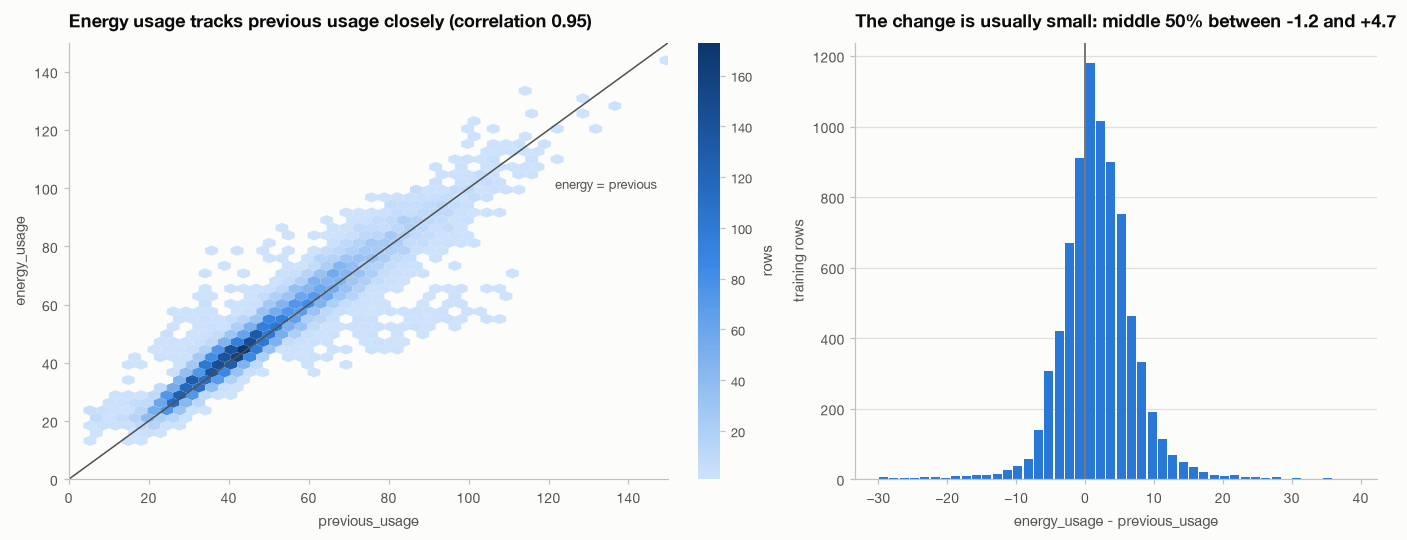

energy_usage - previous_usage: mean +1.60, std 6.20 (compared with a target std of 18.45)


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), gridspec_kw={'width_ratios': [1.15, 1]})
hb = axes[0].hexbin(train['previous_usage'], train[TARGET], gridsize=45, cmap=BLUES, mincnt=1, linewidths=0)
lim = [0, 150]
axes[0].plot(lim, lim, color=INK_2, linewidth=1)
axes[0].text(147, 104, 'energy = previous', ha='right', va='top', fontsize=8.5, color=INK_2,
             bbox=dict(facecolor=SURFACE, edgecolor='none', pad=1))
axes[0].set_xlim(lim)
axes[0].set_ylim(lim)
axes[0].set_xlabel('previous_usage')
axes[0].set_ylabel('energy_usage')
axes[0].grid(False)
r = train[['previous_usage', TARGET]].corr().iloc[0, 1]
axes[0].set_title(f'Energy usage tracks previous usage closely (correlation {r:.2f})')
clean_colorbar(fig.colorbar(hb, ax=axes[0], label='rows'))

delta = train[TARGET] - train['previous_usage']
axes[1].hist(delta.dropna(), bins=np.arange(-30, 40, 1.5), color=TRAIN, rwidth=0.88)
axes[1].axvline(0, color=INK_2, linewidth=1)
value_grid_only(axes[1])
axes[1].set_xlabel('energy_usage - previous_usage')
axes[1].set_ylabel('training rows')
axes[1].set_title(f'The change is usually small: middle 50% between {delta.quantile(.25):+.1f} and {delta.quantile(.75):+.1f}')
plt.show()

print(f'energy_usage - previous_usage: mean {delta.mean():+.2f}, std {delta.std():.2f} '
      f'(compared with a target std of {train[TARGET].std():.2f})')

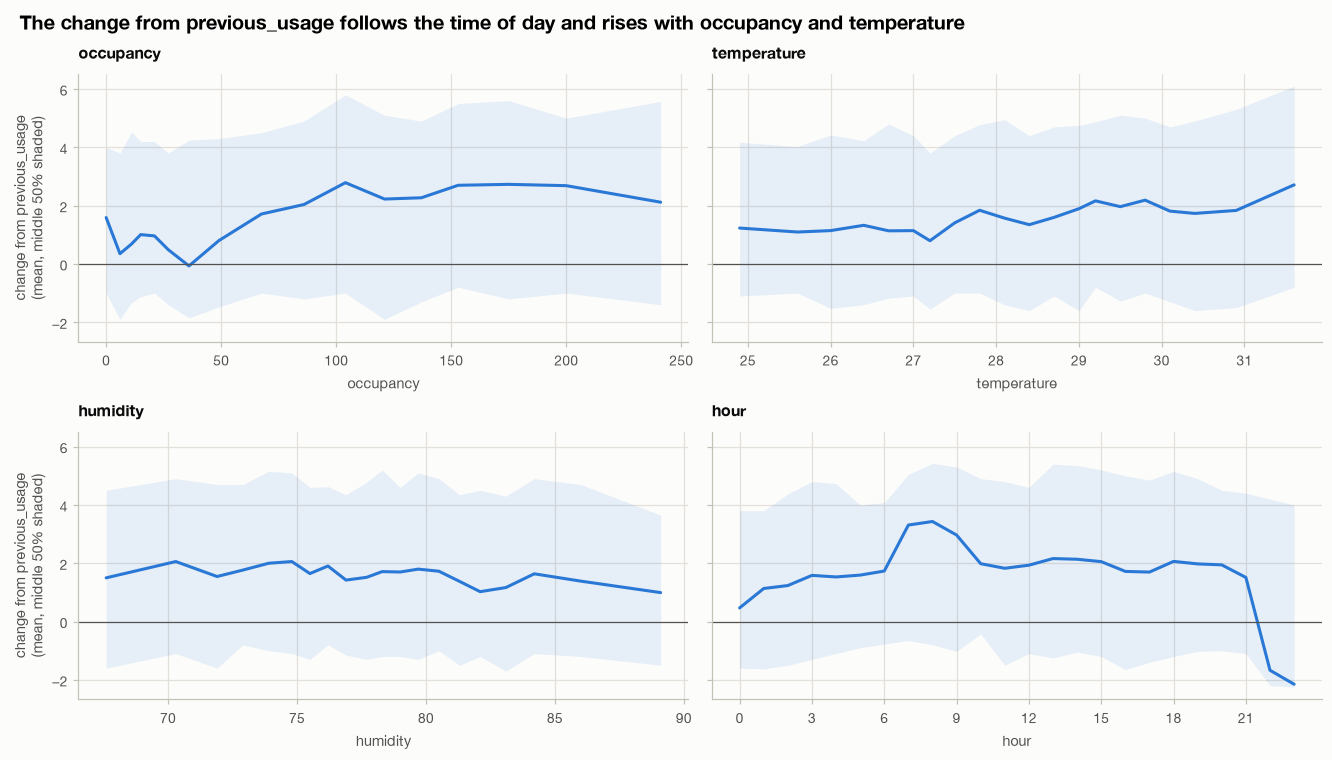

In [40]:
change = train.assign(change=delta)
fig, axes = plt.subplots(2, 2, figsize=(12, 6.8), sharey=True)
for ax, c in zip(axes.flat, ['occupancy', 'temperature', 'humidity', 'hour']):
    if c == 'hour':
        profile(ax, change['hour'], change['change'])
        ax.set_xticks(range(0, 24, 3))
    else:
        binned_profile(ax, change[c], change['change'])
    ax.axhline(0, color=INK_2, linewidth=0.8)
    ax.set_xlabel(c)
    ax.set_title(c, fontsize=10.5)
for ax in axes[:, 0]:
    ax.set_ylabel('change from previous_usage\n(mean, middle 50% shaded)')
fig.suptitle('The change from previous_usage follows the time of day and rises with occupancy and temperature', x=0.01, ha='left')
plt.show()

Do the drivers work the same way in every building? The table fits a separate straight-line model in each building, `energy_usage ~ previous_usage + occupancy + temperature + humidity`, on rows with no blanks. Each coefficient is the change in `energy_usage` for one more unit of that input, holding the others fixed.

In [41]:
rows = []
for b in BUILDINGS:
    sub = train[(train['building_id'] == b)].dropna(subset=NUM)
    X, yb = sub[NUM], sub[TARGET]
    lr = LinearRegression().fit(X, yb)
    rows.append({'building': BLABEL[b], 'rows': len(sub),
                 **{f'per +1 {c}': v for c, v in zip(NUM, lr.coef_)},
                 'R² (in sample)': lr.score(X, yb)})
slopes = pd.DataFrame(rows).set_index('building')
slopes['per +100 occupancy'] = slopes['per +1 occupancy'] * 100
slopes[['rows', 'per +1 previous_usage', 'per +100 occupancy', 'per +1 temperature', 'per +1 humidity', 'R² (in sample)']]

,rows,per +1 previous_usage,per +100 occupancy,per +1 temperature,per +1 humidity,R² (in sample)
building,,,,,,
SCI_A · Science,715,0.35,11.90,2.70,0.16,0.94
SCI_B · Science,628,0.35,10.60,2.66,0.06,0.93
ENG_A · Engineering,718,0.35,11.07,2.28,0.06,0.96
SPT_A · Sports,527,0.37,8.07,1.69,0.05,0.90
ENG_B · Engineering,652,0.34,10.65,2.09,0.06,0.95
RES_A · Residential,571,0.49,4.48,0.38,-0.01,0.74
BUS_B · Business,625,0.42,9.76,1.39,0.03,0.94
RES_B · Residential,560,0.56,4.02,0.33,-0.01,0.72
LIB_A · Library,660,0.39,7.50,1.49,0.04,0.95


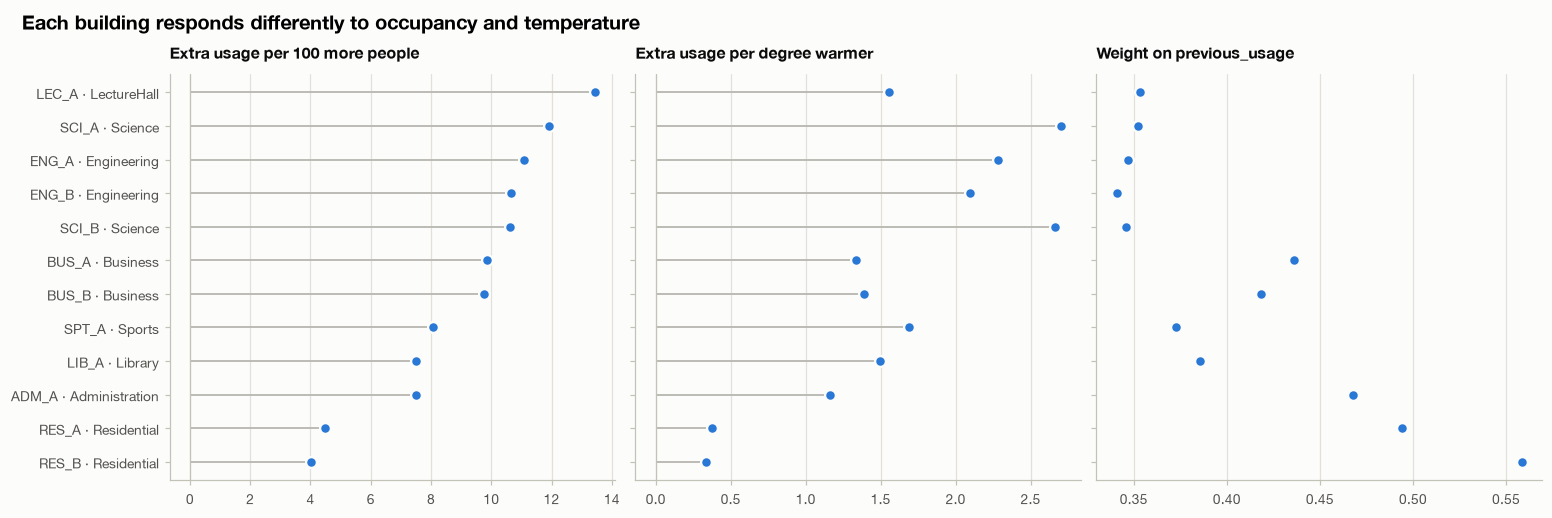

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharey=True)
order = slopes.sort_values('per +100 occupancy', ascending=False).index
for ax, c, title in [(axes[0], 'per +100 occupancy', 'Extra usage per 100 more people'),
                     (axes[1], 'per +1 temperature', 'Extra usage per degree warmer'),
                     (axes[2], 'per +1 previous_usage', 'Weight on previous_usage')]:
    v = slopes.loc[order, c]
    if c != 'per +1 previous_usage':          # stems only where the axis starts at zero
        ax.hlines(range(len(v)), 0, v, color=GRAY, linewidth=1.2)
        ax.axvline(0, color=AXIS, linewidth=0.8)
    ax.scatter(v, range(len(v)), s=50, color=TRAIN, edgecolor=SURFACE, linewidth=1.5, zorder=3)
    ax.set_title(title, fontsize=10.5)
    value_grid_only(ax, horizontal=True)
axes[0].set_yticks(range(len(order)), labels=order)
axes[0].invert_yaxis()
fig.suptitle('Each building responds differently to occupancy and temperature', x=0.01, ha='left')
plt.show()

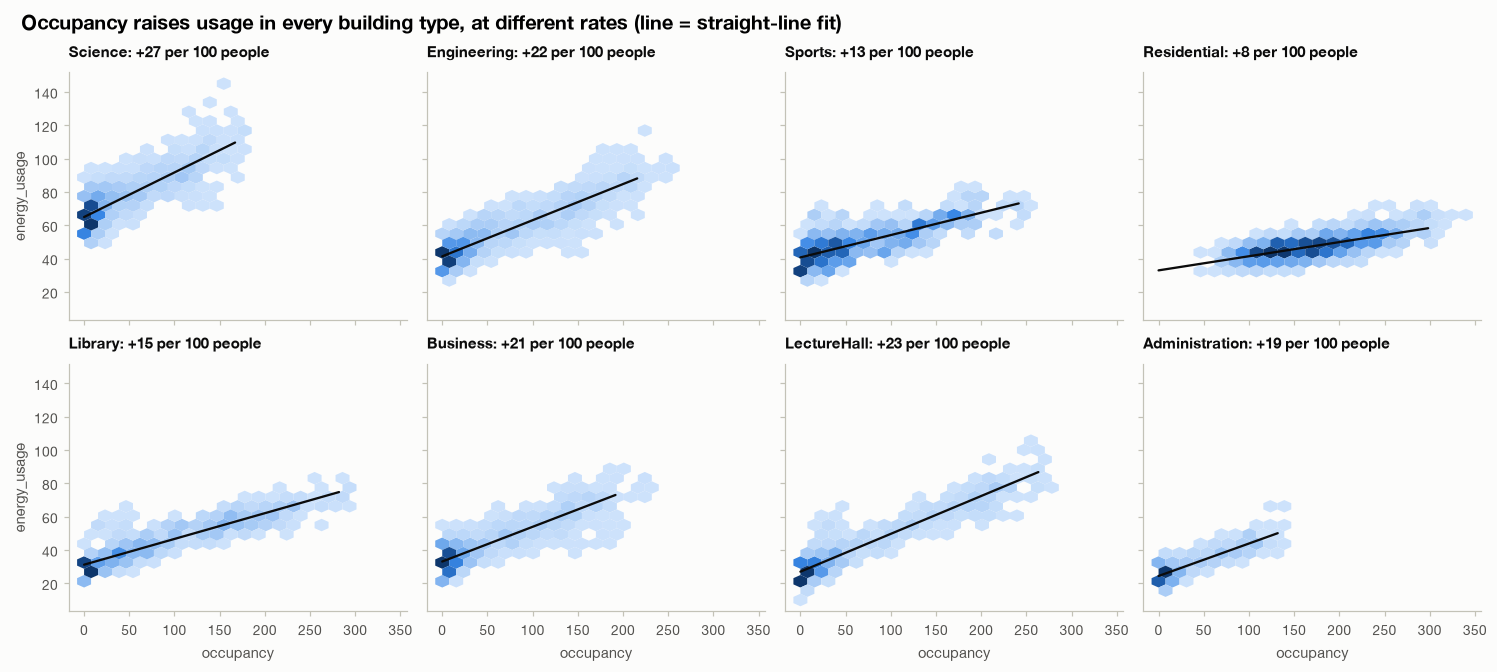

In [43]:
fig, axes = plt.subplots(2, 4, figsize=(13.5, 6), sharex=True, sharey=True)
for ax, t in zip(axes.flat, TYPES):
    sub = train[train['building_type'] == t].dropna(subset=['occupancy'])
    ax.hexbin(sub['occupancy'], sub[TARGET], gridsize=22, cmap=BLUES, mincnt=1, linewidths=0, extent=(0, 340, 10, 145))
    fit = np.polyfit(sub['occupancy'], sub[TARGET], 1)
    xs = np.array([0, sub['occupancy'].quantile(.99)])
    ax.plot(xs, np.polyval(fit, xs), color=INK, linewidth=1.5)
    ax.set_title(f'{t}: {fit[0] * 100:+.0f} per 100 people', fontsize=9.5)
    ax.grid(False)
for ax in axes[1]:
    ax.set_xlabel('occupancy')
for ax in axes[:, 0]:
    ax.set_ylabel('energy_usage')
fig.suptitle('Occupancy raises usage in every building type, at different rates (line = straight-line fit)', x=0.01, ha='left')
plt.show()

**What this shows**

- **`energy_usage` is roughly `previous_usage` plus a small change.** The change has a standard deviation of 6.2, against 18.4 for the target itself. Predicting it well is the real task.
- **The change follows the time of day:** usage jumps about 3.5 above `previous_usage` at 7–9 am as buildings wake up, and falls about 2 below it at 10–11 pm. That fits `previous_usage` being the previous hour's usage.
- **The change rises with occupancy and temperature.** Humidity has little effect.
- **Buildings respond differently.** Per 100 extra people, usage rises about 4 in Residential buildings but 11–13 in Science, Engineering and LectureHall. Per degree warmer, it rises 0.3 in Residential but 2.7 in Science. Within a building, `previous_usage` gets a weight of only 0.34–0.56 once occupancy and temperature are in the model, because those explain much of the same variation.
- A model with one shared slope for all buildings under-predicts the most responsive buildings (Science and LectureHall in particular). That's why giving each building its own slopes (interaction features) helped so much in `linearregression.ipynb`.

## 10. How the test set differs from the training set

**Adversarial validation:** train a classifier to tell training rows from test rows. If it can't (AUC about 0.5), the files look alike. Only rows with no blanks are used, so the blank rate itself doesn't give the answer away.

Train-vs-test classifier AUC (5-fold, rows with no blanks): 0.666


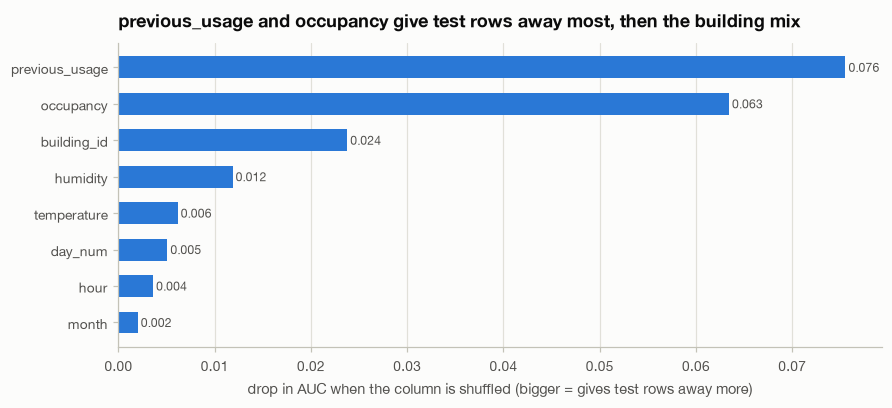

In [44]:
complete_both = both.dropna(subset=NUM)
Xa = complete_both[['hour', 'month', 'day_num'] + NUM].copy()
Xa['building_id'] = complete_both['building_id'].astype('category')
ya = (complete_both['split'] == 'test').astype(int).values
adv_auc = cv_auc(Xa, ya)
print(f'Train-vs-test classifier AUC (5-fold, rows with no blanks): {adv_auc:.3f}')

X_fit, X_hold, y_fit, y_hold = train_test_split(Xa, ya, test_size=0.3, stratify=ya, random_state=0)
clf = HistGradientBoostingClassifier(categorical_features='from_dtype', max_iter=100, learning_rate=0.05,
                                     max_leaf_nodes=15, random_state=0).fit(X_fit, y_fit)
imp = permutation_importance(clf, X_hold, y_hold, scoring='roc_auc', n_repeats=10, random_state=0)
imp = pd.Series(imp.importances_mean, index=Xa.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(imp.index, imp.values, color=TRAIN, height=0.6)
for i, v in enumerate(imp.values):
    ax.text(max(v, 0), i, f' {v:.3f}', va='center', fontsize=8, color=INK_2)
value_grid_only(ax, horizontal=True)
ax.set_xlabel('drop in AUC when the column is shuffled (bigger = gives test rows away more)')
ax.set_title('previous_usage and occupancy give test rows away most, then the building mix')
plt.show()

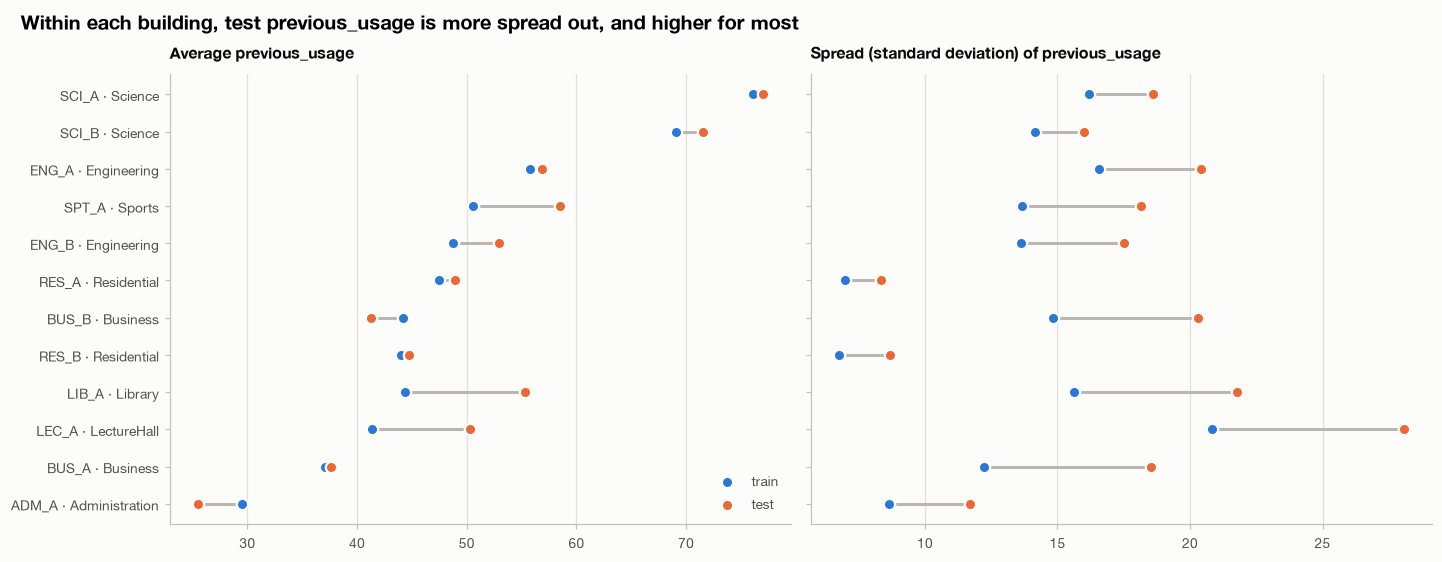

In [45]:
stat = both.groupby(['building_id', 'split'])['previous_usage'].agg(['mean', 'std']).unstack().loc[BUILDINGS]
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, s, title in [(axes[0], 'mean', 'Average previous_usage'), (axes[1], 'std', 'Spread (standard deviation) of previous_usage')]:
    tr_v, te_v = stat[(s, 'train')], stat[(s, 'test')]
    pos = np.arange(len(BUILDINGS))
    ax.hlines(pos, np.minimum(tr_v, te_v), np.maximum(tr_v, te_v), color=GRAY, linewidth=2)
    ax.scatter(tr_v, pos, s=55, color=TRAIN, edgecolor=SURFACE, linewidth=1.5, zorder=3, label='train')
    ax.scatter(te_v, pos, s=55, color=TEST, edgecolor=SURFACE, linewidth=1.5, zorder=3, label='test')
    ax.set_title(title, fontsize=10.5)
    value_grid_only(ax, horizontal=True)
axes[0].set_yticks(range(len(BUILDINGS)), labels=[BLABEL[b] for b in BUILDINGS])
axes[0].invert_yaxis()
axes[0].legend(loc='lower right')
fig.suptitle('Within each building, test previous_usage is more spread out, and higher for most', x=0.01, ha='left')
plt.show()

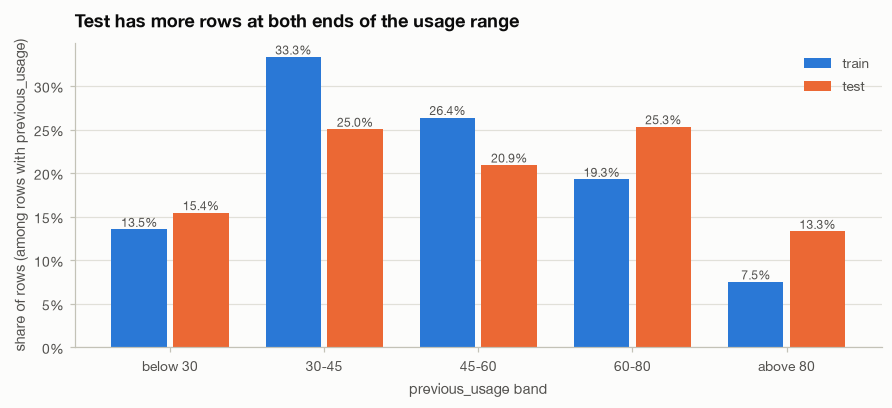

,train,test
previous_usage band,,
below 30,13.53,15.45
30-45,33.32,25.03
45-60,26.38,20.92
60-80,19.27,25.31
above 80,7.49,13.30


In [46]:
BANDS = [0, 30, 45, 60, 80, 200]
BAND_LABELS = ['below 30', '30-45', '45-60', '60-80', 'above 80']
band_share = pd.DataFrame({name: pd.cut(df['previous_usage'], BANDS, labels=BAND_LABELS).value_counts(normalize=True).reindex(BAND_LABELS).values * 100
                           for name, df in [('train', train), ('test', test)]}, index=BAND_LABELS)
fig, ax = plt.subplots(figsize=(8, 3.6))
grouped_bars(ax, BAND_LABELS, band_share['train'], band_share['test'], fmt='{:.1f}%')
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(decimals=0))
ax.set_xlabel('previous_usage band')
ax.set_ylabel('share of rows (among rows with previous_usage)')
ax.set_title('Test has more rows at both ends of the usage range')
plt.show()
band_share.rename_axis('previous_usage band')

**What this shows**

- **The files can be told apart** (AUC about 0.67, where 0.5 would mean identical). The differences come mostly from `previous_usage` and occupancy, then the building mix. Hours, days and months contribute almost nothing.
- **Within every building, test `previous_usage` is more spread out**, and for 10 of 12 buildings it is also higher on average. The test set holds more unusually high *and* unusually low usage rows.
- Rows with `previous_usage` above 80 make up 13% of test but only 7.5% of train. As section 12 shows, those are the hardest rows to predict. Section 11 explains where the extra extreme rows come from.

## 11. Unusual rows: weather events, crowd surges and usage spikes

The histograms in section 7 have bumps that train barely has. To find these rows, each value is compared with the **typical value for the same building, hour and weekday/weekend** (the median in train). Six flags mark the unusual rows:

| Flag | Rule |
|---|---|
| heat | temperature of 33.5° or more |
| rain | humidity of 93% or more |
| occupancy surge | 100 or more people above typical |
| occupancy drop | 60 or more people below typical |
| previous_usage spike | more than 1.6 times typical |
| previous_usage drop | less than half of typical |

The thresholds sit where the train and test distributions separate. They are a practical way to find these rows, not exact definitions.

In [47]:
key = ['building_id', 'hour', 'is_weekend']
typical = train.groupby(key)[['occupancy', 'previous_usage', TARGET]].median().add_suffix(' (typical)')


def event_flags(df):
    d = df.join(typical, on=key)
    return pd.DataFrame({
        'heat': d['temperature'] >= 33.5,
        'rain': d['humidity'] >= 93,
        'occupancy surge': d['occupancy'] - d['occupancy (typical)'] >= 100,
        'occupancy drop': d['occupancy'] - d['occupancy (typical)'] <= -60,
        'previous_usage spike': d['previous_usage'] / d['previous_usage (typical)'] > 1.6,
        'previous_usage drop': d['previous_usage'] / d['previous_usage (typical)'] < 0.5,
    }, index=df.index)


flags_train, flags_test = event_flags(train), event_flags(test)
EVENTS = list(flags_train.columns)
events = pd.DataFrame({'train rows': flags_train.sum(), '% of train': flags_train.mean() * 100,
                       'test rows': flags_test.sum(), '% of test': flags_test.mean() * 100})
events.loc['any of the six'] = [flags_train.any(axis=1).sum(), flags_train.any(axis=1).mean() * 100,
                                flags_test.any(axis=1).sum(), flags_test.any(axis=1).mean() * 100]
events['test / train'] = events['% of test'] / events['% of train']
events[['train rows', 'test rows']] = events[['train rows', 'test rows']].astype(int)
print(f"Rows with two or more flags: train {(flags_train.sum(axis=1) >= 2).sum()}, test {(flags_test.sum(axis=1) >= 2).sum()}")
events

Rows with two or more flags: train 51, test 91


,train rows,% of train,test rows,% of test,test / train
heat,72,0.90,130,4.33,4.81
rain,78,0.97,131,4.37,4.48
occupancy surge,130,1.62,259,8.63,5.31
occupancy drop,18,0.22,39,1.30,5.78
previous_usage spike,114,1.43,235,7.83,5.50
previous_usage drop,51,0.64,90,3.00,4.71
any of the six,408,5.10,784,26.13,5.12


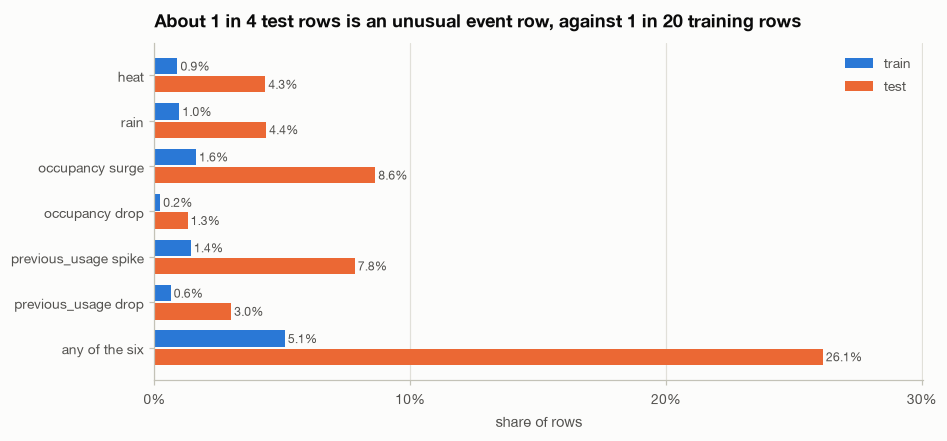

In [48]:
fig, ax = plt.subplots(figsize=(8.5, 3.9))
grouped_bars(ax, events.index, events['% of train'], events['% of test'], horizontal=True, fmt='{:.1f}%')
pct_axis(ax, 'x')
ax.set_xlim(0, events['% of test'].max() * 1.15)
ax.set_xlabel('share of rows')
ax.legend(loc='upper right')
ax.set_title('About 1 in 4 test rows is an unusual event row, against 1 in 20 training rows')
plt.show()

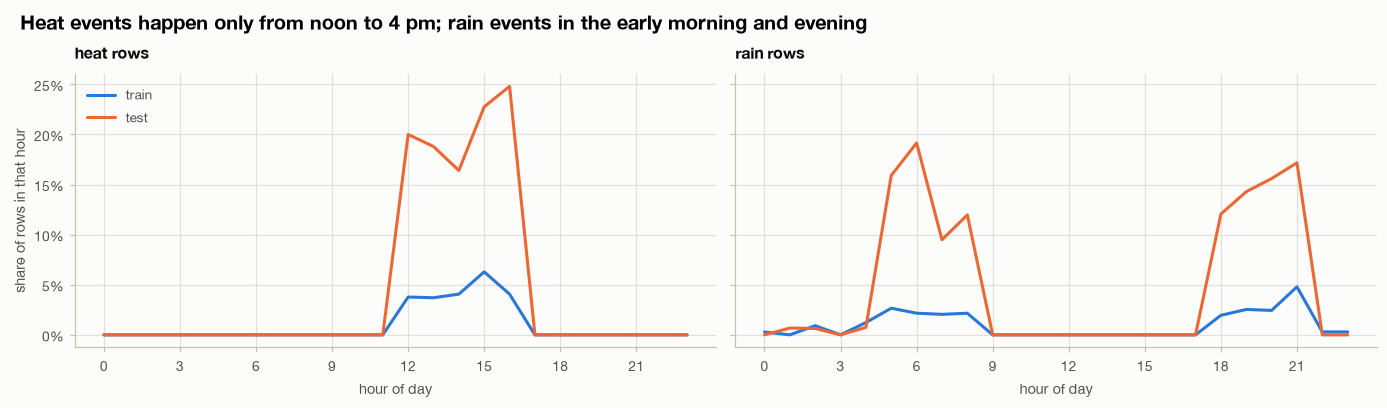

train: heat rows average 85% humidity (other rows 78%); rain rows average 24.5° (other rows 28.3°)
test: heat rows average 84% humidity (other rows 79%); rain rows average 24.3° (other rows 28.4°)


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.6), sharey=True)
for ax, e in zip(axes, ['heat', 'rain']):
    for name, df, fl, color in [('train', train, flags_train, TRAIN), ('test', test, flags_test, TEST)]:
        share = fl[e].groupby(df['hour']).mean() * 100
        ax.plot(share.index, share.values, color=color, label=name)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlabel('hour of day')
    ax.set_title(f'{e} rows', fontsize=10.5)
pct_axis(axes[0])
axes[0].set_ylabel('share of rows in that hour')
axes[0].legend(loc='upper left')
fig.suptitle('Heat events happen only from noon to 4 pm; rain events in the early morning and evening', x=0.01, ha='left')
plt.show()

for name, df, fl in [('train', train, flags_train), ('test', test, flags_test)]:
    print(f"{name}: heat rows average {df.loc[fl['heat'], 'humidity'].mean():.0f}% humidity (other rows {df.loc[~fl['heat'], 'humidity'].mean():.0f}%); "
          f"rain rows average {df.loc[fl['rain'], 'temperature'].mean():.1f}° (other rows {df.loc[~fl['rain'], 'temperature'].mean():.1f}°)")

**Does `energy_usage` follow these events?** If an unusual value were a recording error, `energy_usage` in that row would look normal. If the event is real, `energy_usage` moves with it. The table compares each flagged training row with the typical value for its building, hour and weekday/weekend (1.00 = typical).

In [50]:
d = train.join(typical, on=key)
ratio_prev = d['previous_usage'] / d['previous_usage (typical)']
ratio_energy = d[TARGET] / d[f'{TARGET} (typical)']
occ_gap = d['occupancy'] - d['occupancy (typical)']
rows = []
for name, m in [('no flag', ~flags_train.any(axis=1))] + [(e, flags_train[e]) for e in EVENTS]:
    rows.append({'training rows': name, 'count': int(m.sum()),
                 'previous_usage vs typical': ratio_prev[m].median(),
                 'energy_usage vs typical': ratio_energy[m].median(),
                 'occupancy minus typical': occ_gap[m].median(),
                 'temperature': d.loc[m, 'temperature'].median(),
                 'humidity': d.loc[m, 'humidity'].median()})
pd.DataFrame(rows).set_index('training rows')

,count,previous_usage vs typical,energy_usage vs typical,occupancy minus typical,temperature,humidity
training rows,,,,,,
no flag,7592,1.00,1.00,0.00,28.20,77.80
heat,72,1.38,1.36,47.50,34.80,85.00
rain,78,0.88,0.85,0.00,24.50,96.85
occupancy surge,130,1.34,1.39,154.00,29.80,77.40
occupancy drop,18,0.87,0.89,-106.00,29.85,76.80
previous_usage spike,114,1.96,1.40,8.00,28.05,79.00
previous_usage drop,51,0.36,0.82,-1.50,26.40,80.65


**What this shows**

- **26% of test rows are unusual event rows, against 5% of training rows.** Every kind of event is about five times as common in test (4.5–5.8x). This is the biggest difference between the files and the main reason the test set's numbers are more spread out (section 7) and easy to tell apart (section 10).
- **The events look like real situations, not recording errors:**
  - *Heat* rows happen only from noon to 4 pm and are humid (about 85%), like a heat wave. Usage is about 36% above typical, with more people in the building.
  - *Rain* rows are cool (about 24°) and happen early in the morning or in the evening. Usage is about 15% below typical.
  - *Occupancy surges* (about 150 extra people) come with about 39% higher usage. *Occupancy drops* come with about 11% lower usage.
  - After a *`previous_usage` spike* (about twice typical), usage stays high, about 40% above typical, but drops back part of the way. After a *drop* (about a third of typical), usage recovers most of the way, to about 80% of typical.
- Because `energy_usage` responds to these events, a model should use the unusual values rather than treat them as errors. The model just has few training examples of them: about 400 training rows against about 780 test rows.

## 12. Noise and predictability

How much of `energy_usage` can be predicted at all? A simple model gives a sense of the floor: a separate straight-line model per building using `previous_usage`, occupancy, temperature, humidity, hour and weekend, scored with 5-fold cross-validation on rows with no blanks. Its errors (residuals) show where predictions are hard.

In [51]:
data = train.dropna(subset=NUM).copy()
data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)
data['weekend'] = data['is_weekend'].astype(float)
inputs = NUM + ['hour_sin', 'hour_cos', 'weekend']

data['predicted'] = np.nan
for b in BUILDINGS:
    sub = data[data['building_id'] == b]
    data.loc[sub.index, 'predicted'] = cross_val_predict(LinearRegression(), sub[inputs], sub[TARGET],
                                                         cv=KFold(5, shuffle=True, random_state=0))
data['error'] = data['predicted'] - data[TARGET]
rmse = np.sqrt((data['error'] ** 2).mean())
r2 = 1 - (data['error'] ** 2).sum() / ((data[TARGET] - data[TARGET].mean()) ** 2).sum()
print(f'Per-building straight-line model: RMSE {rmse:.2f}, R² {r2:.3f} (5-fold cross-validation, {len(data):,} rows)')

Per-building straight-line model: RMSE 3.12, R² 0.972 (5-fold cross-validation, 7,537 rows)


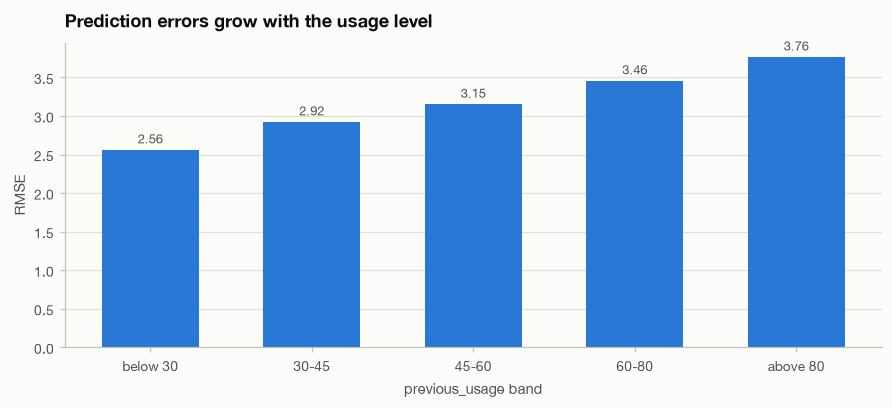

,rows,mean error (bias),RMSE,RMSE as % of mean usage
below 30,1021,0.05,2.56,9.33
30-45,2521,-0.02,2.92,7.26
45-60,1984,-0.07,3.15,5.87
60-80,1447,0.09,3.46,4.99
above 80,564,-0.02,3.76,4.25


In [52]:
data['band'] = pd.cut(data['previous_usage'], BANDS, labels=BAND_LABELS)
by_band = data.groupby('band', observed=True)['error'].agg(
    rows='count', **{'mean error (bias)': 'mean'}, RMSE=lambda e: np.sqrt((e ** 2).mean()))
by_band['RMSE as % of mean usage'] = by_band['RMSE'] / data.groupby('band', observed=True)[TARGET].mean() * 100
by_band.index = BAND_LABELS

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(BAND_LABELS, by_band['RMSE'], color=TRAIN, width=0.6)
for i, v in enumerate(by_band['RMSE']):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center', va='bottom', fontsize=8.5, color=INK_2)
value_grid_only(ax)
ax.set_xlabel('previous_usage band')
ax.set_ylabel('RMSE')
ax.set_title('Prediction errors grow with the usage level')
plt.show()
by_band

In [53]:
by_b = data.groupby('building_id')['error'].agg(**{'mean error (bias)': 'mean'}, RMSE=lambda e: np.sqrt((e ** 2).mean()))
by_b = by_b.loc[by_b['RMSE'].sort_values(ascending=False).index]
by_b.index = [BLABEL[b] for b in by_b.index]

w = band_share.loc[BAND_LABELS] / 100
mix_train = np.sqrt((w['train'] * by_band['RMSE'] ** 2).sum() / w['train'].sum())
mix_test = np.sqrt((w['test'] * by_band['RMSE'] ** 2).sum() / w['test'].sum())
print(f'Same model, same error per band, but with the test set\'s mix of usage levels: RMSE {mix_train:.2f} -> {mix_test:.2f}')
by_b

Same model, same error per band, but with the test set's mix of usage levels: RMSE 3.12 -> 3.18


,mean error (bias),RMSE
SCI_A · Science,0.01,3.70
SCI_B · Science,0.01,3.44
SPT_A · Sports,-0.00,3.41
ENG_A · Engineering,-0.01,3.14
RES_B · Residential,0.01,3.12
RES_A · Residential,0.00,3.06
BUS_B · Business,-0.00,3.03
ENG_B · Engineering,0.01,3.00
LIB_A · Library,-0.01,2.98
LEC_A · LectureHall,0.00,2.83


In [54]:
fl = flags_train.loc[data.index]
rows = [{'training rows': 'no flag', 'count': int((~fl.any(axis=1)).sum()),
         'mean error (bias)': data.loc[~fl.any(axis=1), 'error'].mean(),
         'RMSE': np.sqrt((data.loc[~fl.any(axis=1), 'error'] ** 2).mean())}]
for e in EVENTS:
    m = fl[e]
    rows.append({'training rows': e, 'count': int(m.sum()), 'mean error (bias)': data.loc[m, 'error'].mean(),
                 'RMSE': np.sqrt((data.loc[m, 'error'] ** 2).mean())})
display(pd.DataFrame(rows).set_index('training rows'))

is_event = fl.any(axis=1)
rmse_event = np.sqrt((data.loc[is_event, 'error'] ** 2).mean())
rmse_normal = np.sqrt((data.loc[~is_event, 'error'] ** 2).mean())
for name, share in [('train', flags_train.any(axis=1).mean()), ('test', flags_test.any(axis=1).mean())]:
    print(f'Expected RMSE with the {name} share of event rows ({share:.0%}): '
          f'{np.sqrt(share * rmse_event ** 2 + (1 - share) * rmse_normal ** 2):.2f}')

,count,mean error (bias),RMSE
training rows,,,
no flag,7147,0.01,3.10
heat,71,0.32,4.00
rain,72,-1.31,3.15
occupancy surge,125,0.49,3.68
occupancy drop,18,-1.10,2.46
previous_usage spike,110,0.37,3.29
previous_usage drop,49,-0.47,2.72


Expected RMSE with the train share of event rows (5%): 3.12
Expected RMSE with the test share of event rows (26%): 3.17


**What this shows**

- **A simple model already does well:** a separate straight-line model per building reaches an RMSE of 3.12 (R² 0.97) on rows without blanks. That's about as good as the tuned models in `linearregression.ipynb`, so within each building the relationships are close to straight lines.
- **Errors grow with the usage level**, from about 2.6 below 30 to about 3.8 above 80, while the average error (bias) stays near 0 in every band. The extra error at high usage looks like random noise, not something the model systematically gets wrong.
- **Science buildings have the largest errors** (3.4–3.7), Administration the smallest (2.7).
- **Event rows are a bit harder:** heat rows have an RMSE of about 4.0 and occupancy surges about 3.7, and rain rows are under-predicted by about 1.3 on average.
- **What this means for the test score:** with the test set's mix of usage levels, the expected RMSE rises only slightly (3.12 to 3.18). With its share of event rows, it rises by a similar small amount (3.12 to 3.17). The larger part of the gap between validation and test scores comes from the test set's extra blanks (section 4): in the modeling experiments for this project, giving validation rows the test set's blank pattern raised the tuned model's RMSE from about 3.13 to 3.34.

## 13. Summary and modeling implications

**What the data looks like**

- 12 buildings of 8 types, observed at every hour of the day, every day of the week and every month. There are no dates, and the rows are independent snapshots.
- `energy_usage` ≈ `previous_usage` + a change. The change follows the hour, occupancy and temperature, and every building responds to those at its own rate.
- Blanks are random but much more common in test, often two or three in a row.
- The test set has a different building mix, wider-spread values and five times as many unusual event rows.

**Implications for modeling**

| Finding | What to do |
|---|---|
| `energy_usage` ≈ `previous_usage` + a change (section 9) | Model the change. Tree models can predict `energy_usage − previous_usage`; linear models keep `previous_usage` as an input. |
| Each building responds differently to occupancy, temperature, hour and weekends (sections 5 and 9) | Keep `building_id`. Give linear models per-building slopes (interaction features) and a weekend flag that varies by building type. |
| Within a building, relationships are close to straight lines (section 12) | A regularized linear model with interactions is a strong base. Trees add a little in a blend. |
| Day of week (beyond weekend) and month carry little information (sections 5 and 8) | A weekday/weekend flag is enough. Month can stay but matters little. |
| Blanks are random, 4–5 times as common in test, and often two or three per row (section 4) | Blank indicators won't help. Use an imputer that fills several values per row from the others (such as MissForest-style imputation), and test the whole pipeline with test-like blanks. |
| Test has more event rows and more extreme values (sections 10 and 11) | Judge models on test-like validation (reweighted rows or copied blank patterns), not only on a random split of `train.csv`. Consider event flags as features: trees have few examples of these rows to learn from. |
| Noise floor around RMSE 3.1 on training-like rows (section 12) | Expect small returns from further tuning. Remaining gains come from handling blanks and event rows well. |